# Active Learning with Fully Bayesian Neural Nets

*Prepared by Maxim Ziatdinov (August 2024)*

This notebook compares active learning with a standard Gaussian process (GP) and with fully Bayesian neural network (BNN) on a dataset with discontinuities and non-stationarities.

## Imports

In [ ]:
import os
os.environ['XLA_FLAGS'] = '--xla_cpu_use_thunk_runtime=false' # see https://github.com/jax-ml/jax/discussions/23822

In [1]:
import sys
sys.path.append("..")

import neurobayes as nb

import numpy as np
import matplotlib.pyplot as plt

# Uncomment the next two lines to set default precision to 'double' for stability/robustness
# import jax
# jax.config.update("jax_enable_x64", True)

## Data

Create a measurement function and view the ground truth:

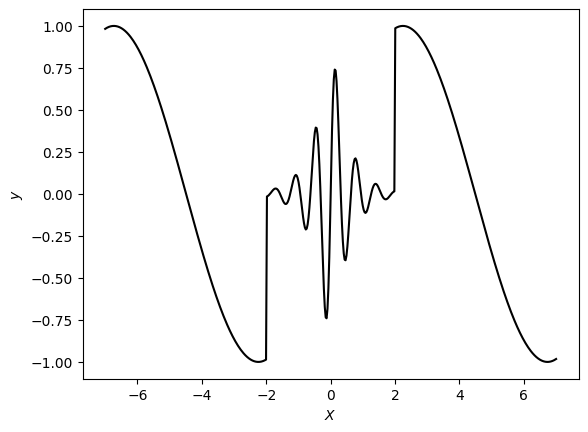

In [2]:
(x_start, x_stop), fn = nb.genfunc.nonstationary2()

measure = lambda x: fn(x) + np.random.normal(0, 0.02, size=len(x))

X_domain = np.linspace(x_start, x_stop, 500)
y_true = fn(X_domain)

plt.plot(X_domain, y_true, c='k')
plt.xlabel("$X$")
plt.ylabel("$y$");

## GP-based active learning

Run standard Gaussian process-based active learning:

step 1


sample: 100%|██████████| 2000/2000 [00:01<00:00, 1924.60it/s, 7 steps of size 4.62e-01. acc. prob=0.94]



                 mean       std    median      5.0%     95.0%     n_eff     r_hat
k_length[0]      1.23      1.35      0.87      0.08      2.49    612.92      1.00
    k_scale      1.07      1.02      0.79      0.04      2.17    585.82      1.00
      noise      0.75      0.53      0.66      0.00      1.46    686.71      1.01



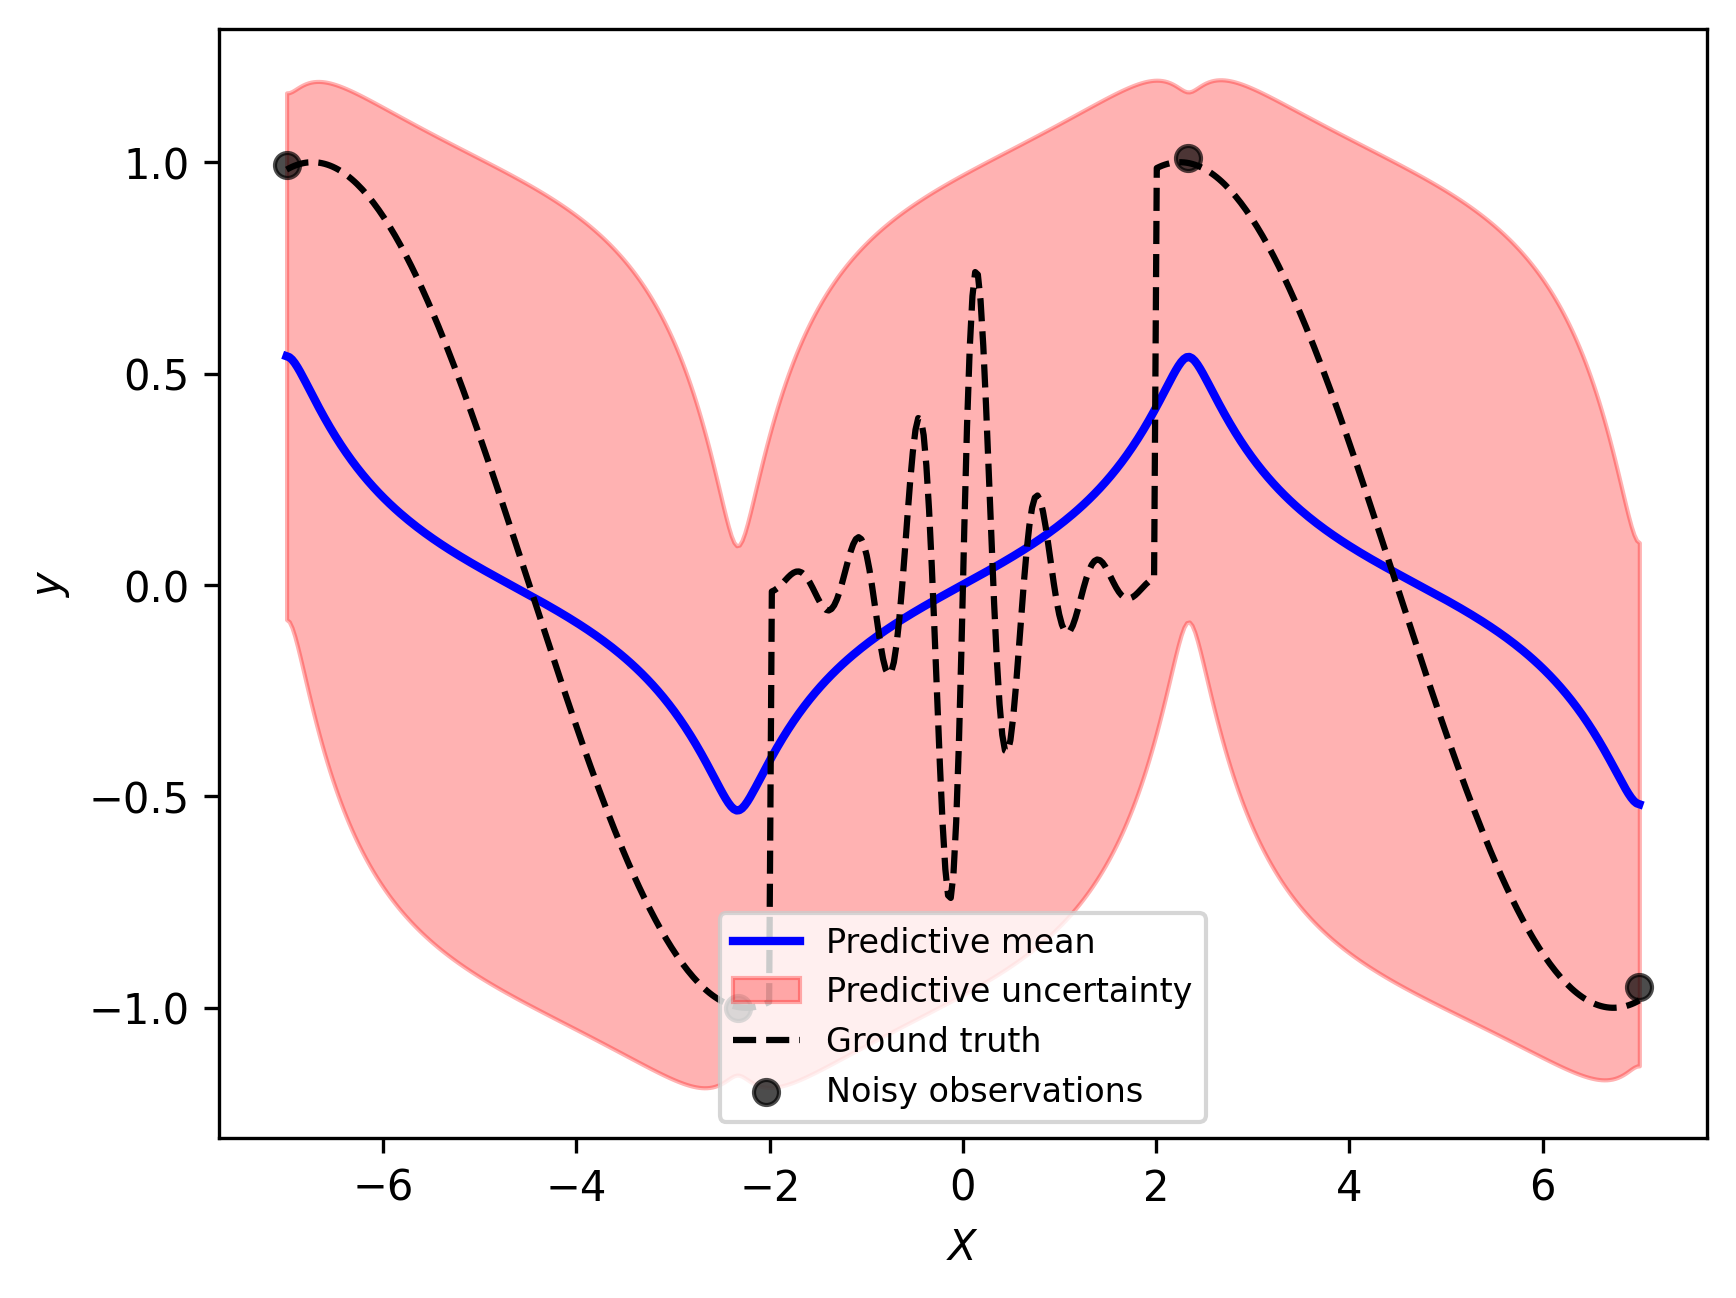

step 2


sample: 100%|██████████| 2000/2000 [00:00<00:00, 2192.27it/s, 7 steps of size 5.02e-01. acc. prob=0.94]



                 mean       std    median      5.0%     95.0%     n_eff     r_hat
k_length[0]      1.23      1.28      0.88      0.07      2.41    643.79      1.00
    k_scale      0.94      0.86      0.69      0.07      1.95    649.52      1.01
      noise      0.68      0.47      0.59      0.00      1.34    580.11      1.01

step 3


sample: 100%|██████████| 2000/2000 [00:00<00:00, 2032.34it/s, 7 steps of size 5.18e-01. acc. prob=0.93]



                 mean       std    median      5.0%     95.0%     n_eff     r_hat
k_length[0]      1.29      1.37      0.90      0.06      2.72    407.37      1.00
    k_scale      0.77      0.66      0.57      0.05      1.59    740.64      1.00
      noise      0.60      0.46      0.51      0.00      1.16    650.86      1.01

step 4


sample: 100%|██████████| 2000/2000 [00:00<00:00, 2121.01it/s, 7 steps of size 5.05e-01. acc. prob=0.93]



                 mean       std    median      5.0%     95.0%     n_eff     r_hat
k_length[0]      1.41      1.53      0.94      0.07      2.99    556.78      1.00
    k_scale      0.73      0.64      0.54      0.05      1.46    585.91      1.00
      noise      0.51      0.41      0.42      0.00      1.10    581.18      1.01

step 5


sample: 100%|██████████| 2000/2000 [00:00<00:00, 2124.59it/s, 7 steps of size 4.36e-01. acc. prob=0.94]



                 mean       std    median      5.0%     95.0%     n_eff     r_hat
k_length[0]      1.34      1.40      0.92      0.09      2.88    455.16      1.00
    k_scale      0.63      0.52      0.49      0.04      1.18    611.53      1.00
      noise      0.47      0.35      0.40      0.00      0.93    850.90      1.00



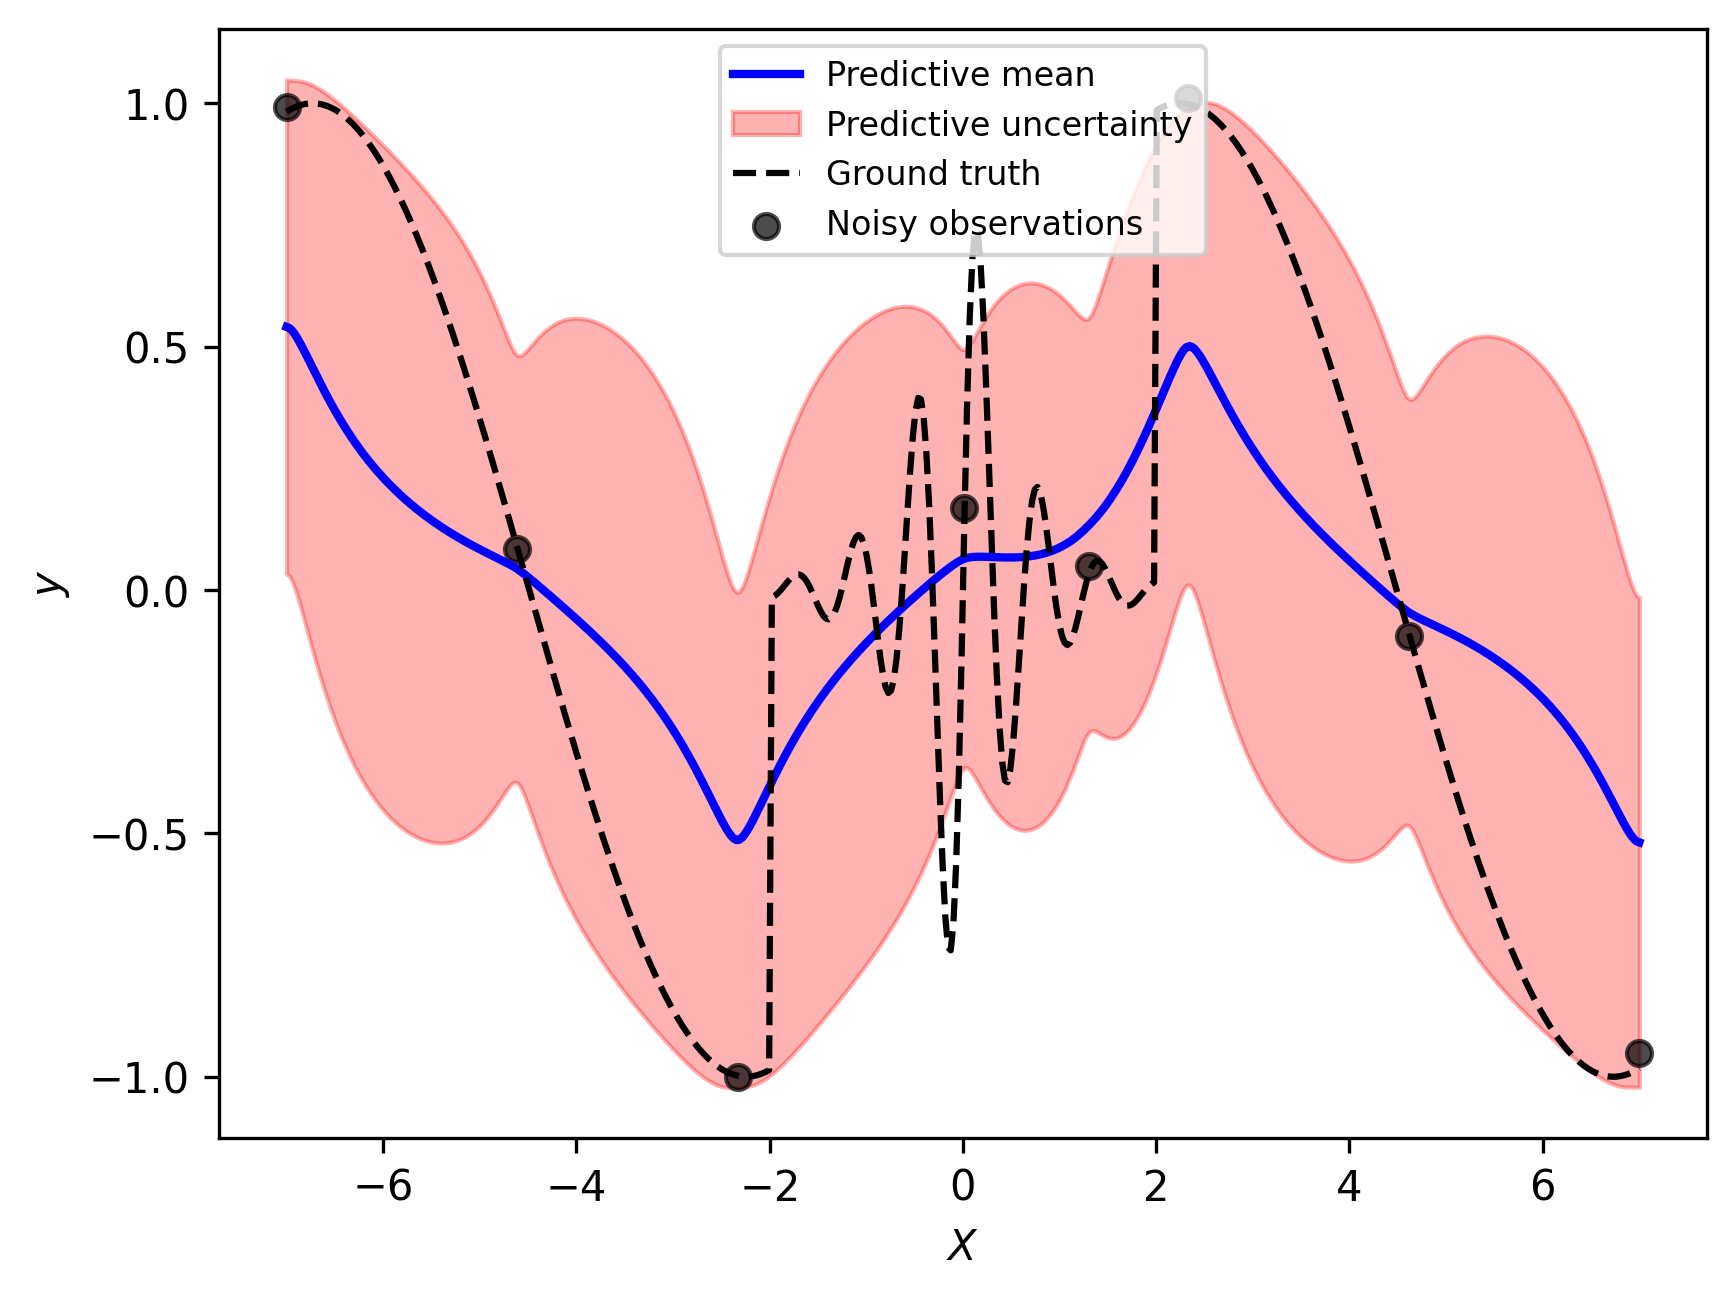

step 6


sample: 100%|██████████| 2000/2000 [00:00<00:00, 2051.22it/s, 7 steps of size 4.86e-01. acc. prob=0.93]



                 mean       std    median      5.0%     95.0%     n_eff     r_hat
k_length[0]      1.49      1.45      1.11      0.13      3.07    643.40      1.00
    k_scale      0.63      0.53      0.50      0.05      1.20    574.41      1.01
      noise      0.42      0.33      0.33      0.00      0.86    848.49      1.00

step 7


sample: 100%|██████████| 2000/2000 [00:01<00:00, 1878.44it/s, 7 steps of size 4.36e-01. acc. prob=0.93]



                 mean       std    median      5.0%     95.0%     n_eff     r_hat
k_length[0]      1.65      1.55      1.28      0.10      3.20    547.15      1.00
    k_scale      0.64      0.49      0.52      0.05      1.19    582.71      1.01
      noise      0.34      0.30      0.26      0.00      0.75    600.59      1.00

step 8


...


                 mean       std    median      5.0%     95.0%     n_eff     r_hat
k_length[0]      1.79      1.37      1.52      0.16      3.15    364.29      1.00
    k_scale      0.68      0.51      0.56      0.08      1.29    393.83      1.01
      noise      0.28      0.27      0.19      0.00      0.61    560.03      1.00

step 9


sample: 100%|██████████| 2000/2000 [00:00<00:00, 2022.92it/s, 5 steps of size 4.42e-01. acc. prob=0.92]



                 mean       std    median      5.0%     95.0%     n_eff     r_hat
k_length[0]      1.89      1.11      1.75      0.17      3.25    533.75      1.00
    k_scale      0.70      0.53      0.58      0.11      1.27    462.73      1.01
      noise      0.20      0.21      0.13      0.00      0.52    520.89      1.00

step 10


sample: 100%|██████████| 2000/2000 [00:01<00:00, 1786.63it/s, 7 steps of size 4.27e-01. acc. prob=0.92]



                 mean       std    median      5.0%     95.0%     n_eff     r_hat
k_length[0]      1.85      1.07      1.65      0.25      3.18    466.66      1.00
    k_scale      0.68      0.57      0.53      0.14      1.27    309.89      1.00
      noise      0.18      0.19      0.12      0.00      0.43    738.21      1.00



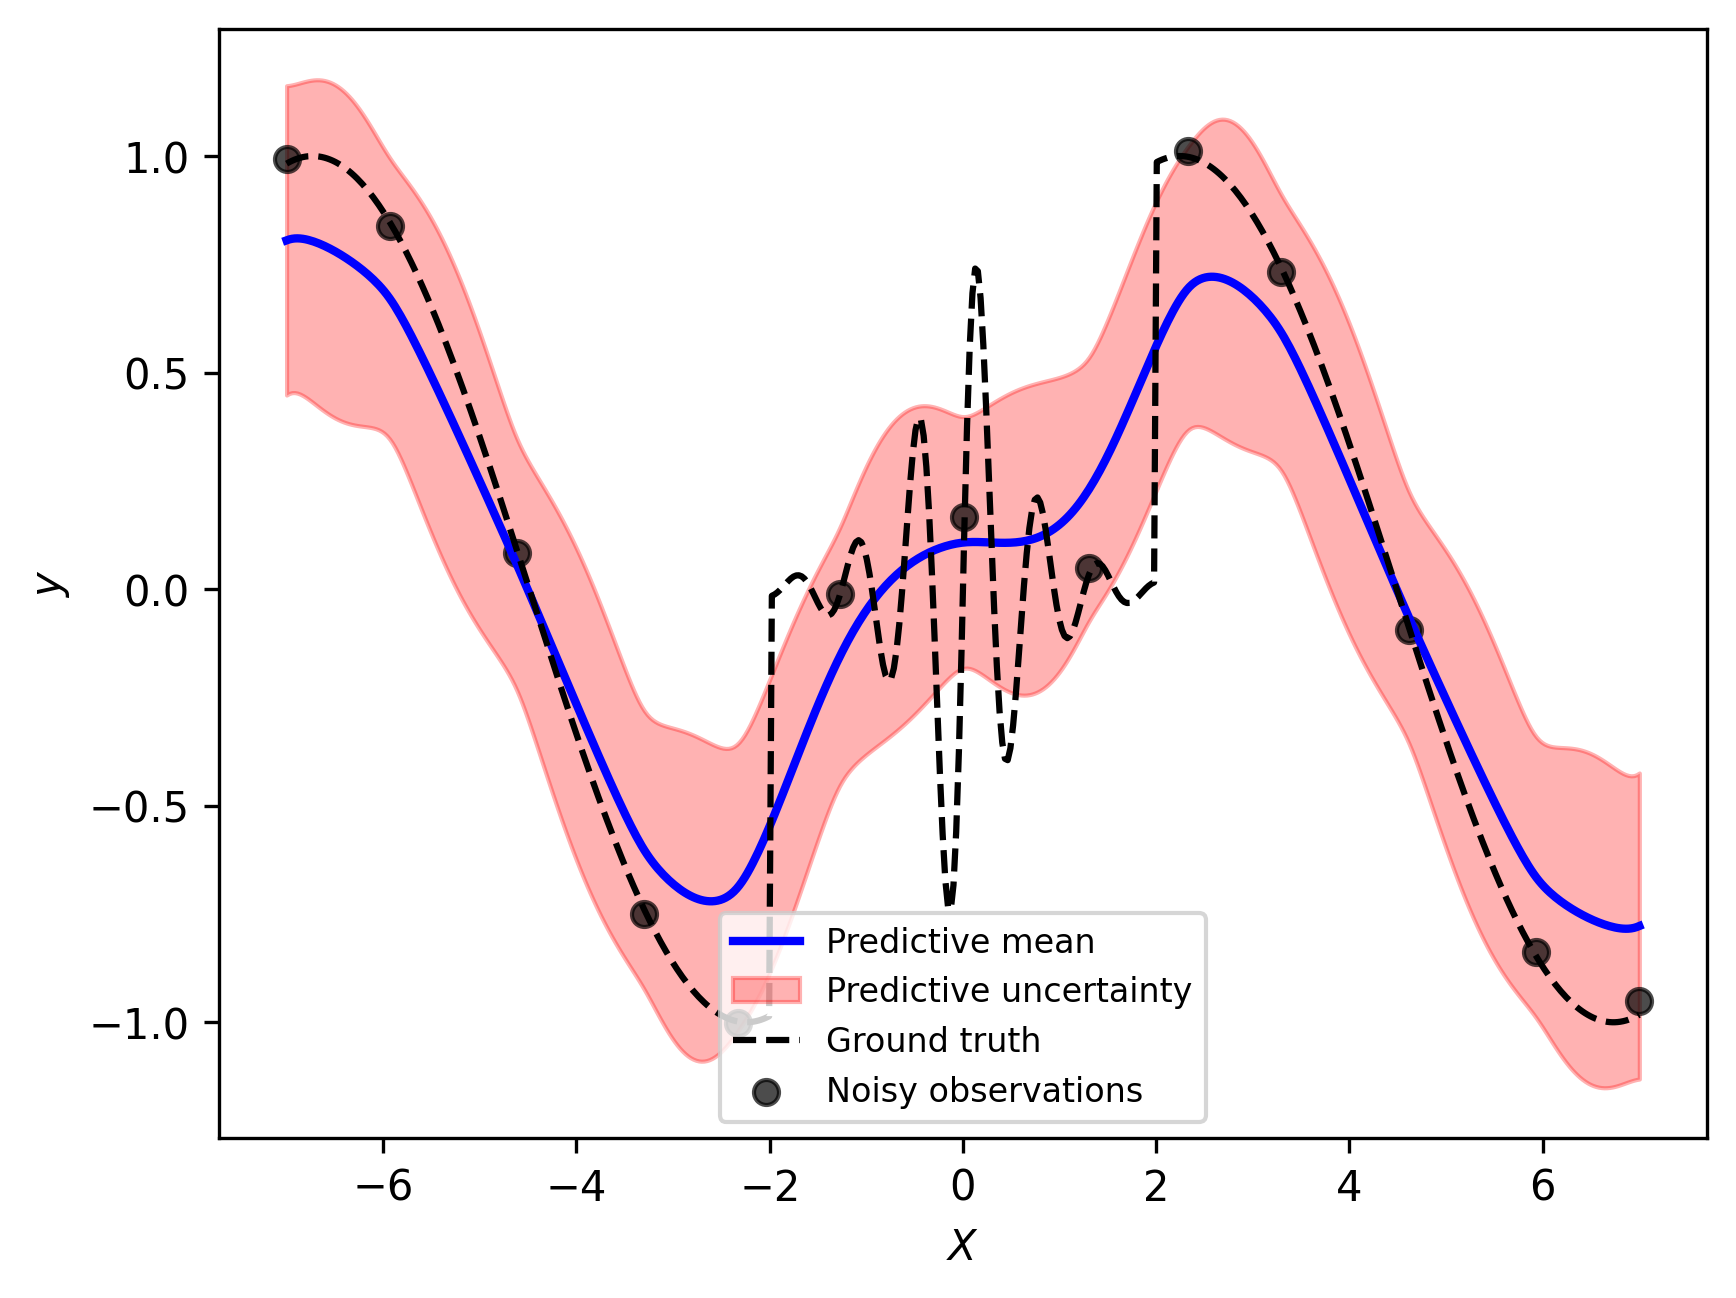

step 11


sample: 100%|██████████| 2000/2000 [00:01<00:00, 1938.58it/s, 7 steps of size 4.07e-01. acc. prob=0.92]



                 mean       std    median      5.0%     95.0%     n_eff     r_hat
k_length[0]      1.89      0.89      1.73      0.55      3.09    443.76      1.01
    k_scale      0.72      0.54      0.56      0.13      1.33    398.20      1.01
      noise      0.11      0.12      0.08      0.00      0.25    598.75      1.00

step 12


sample: 100%|██████████| 2000/2000 [00:01<00:00, 1924.70it/s, 3 steps of size 4.02e-01. acc. prob=0.95]



                 mean       std    median      5.0%     95.0%     n_eff     r_hat
k_length[0]      2.00      0.92      1.85      0.68      3.27    452.52      1.01
    k_scale      0.73      0.59      0.57      0.17      1.37    443.50      1.00
      noise      0.10      0.09      0.07      0.00      0.21    676.58      1.00

step 13


...


                 mean       std    median      5.0%     95.0%     n_eff     r_hat
k_length[0]      2.01      0.81      1.87      0.82      3.16    442.27      1.00
    k_scale      0.75      0.59      0.60      0.18      1.38    349.15      1.00
      noise      0.07      0.08      0.05      0.00      0.15    797.33      1.00

step 14


sample: 100%|██████████| 2000/2000 [00:01<00:00, 1856.12it/s, 7 steps of size 4.55e-01. acc. prob=0.95]



                 mean       std    median      5.0%     95.0%     n_eff     r_hat
k_length[0]      2.04      0.76      1.93      0.80      3.04    499.31      1.02
    k_scale      0.73      0.50      0.57      0.18      1.38    430.66      1.01
      noise      0.06      0.05      0.04      0.00      0.12    810.94      1.00

step 15


sample: 100%|██████████| 2000/2000 [00:01<00:00, 1841.11it/s, 7 steps of size 5.12e-01. acc. prob=0.93]



                 mean       std    median      5.0%     95.0%     n_eff     r_hat
k_length[0]      2.09      0.73      1.99      0.99      3.17    503.56      1.01
    k_scale      0.75      0.54      0.59      0.19      1.40    406.98      1.01
      noise      0.04      0.04      0.03      0.00      0.09    665.34      1.00



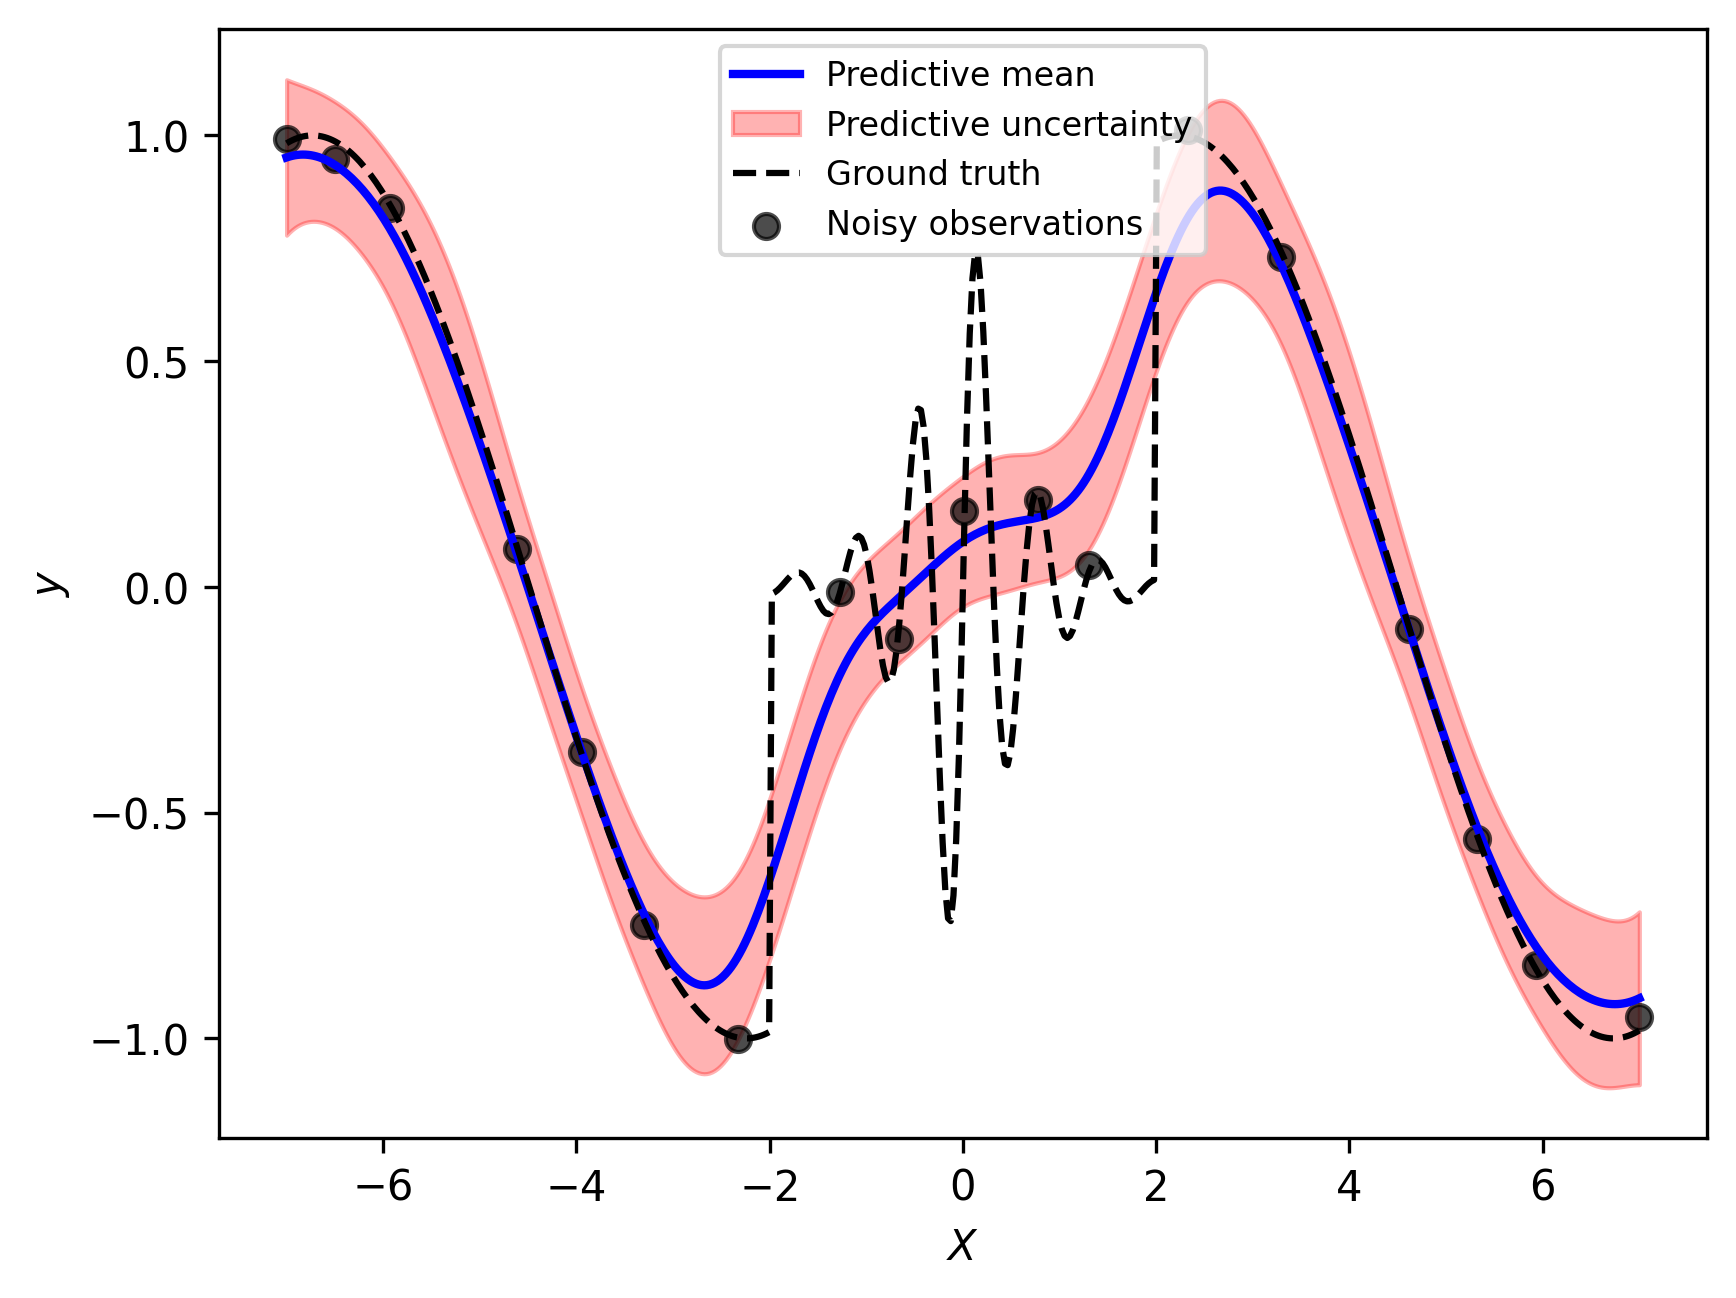

step 16


sample: 100%|██████████| 2000/2000 [00:01<00:00, 1641.21it/s, 7 steps of size 5.08e-01. acc. prob=0.92]



                 mean       std    median      5.0%     95.0%     n_eff     r_hat
k_length[0]      2.09      0.72      2.00      0.92      3.04    462.80      1.01
    k_scale      0.74      0.50      0.60      0.20      1.33    479.22      1.01
      noise      0.04      0.03      0.03      0.00      0.07    855.42      1.00

step 17


sample: 100%|██████████| 2000/2000 [00:01<00:00, 1695.35it/s, 7 steps of size 4.37e-01. acc. prob=0.94]



                 mean       std    median      5.0%     95.0%     n_eff     r_hat
k_length[0]      2.05      0.67      1.95      0.99      2.98    429.13      1.00
    k_scale      0.75      0.52      0.61      0.21      1.35    453.13      1.00
      noise      0.03      0.03      0.02      0.00      0.06    735.58      1.00

step 18


...


                 mean       std    median      5.0%     95.0%     n_eff     r_hat
k_length[0]      2.01      0.63      1.92      1.05      2.87    409.21      1.01
    k_scale      0.75      0.49      0.61      0.20      1.31    359.04      1.00
      noise      0.02      0.02      0.02      0.00      0.05    861.09      1.00

step 19


sample: 100%|██████████| 2000/2000 [00:01<00:00, 1726.84it/s, 7 steps of size 3.64e-01. acc. prob=0.95]



                 mean       std    median      5.0%     95.0%     n_eff     r_hat
k_length[0]      1.93      0.55      1.84      1.11      2.77    436.24      1.01
    k_scale      0.73      0.48      0.59      0.19      1.29    474.69      1.00
      noise      0.02      0.01      0.01      0.00      0.03    673.03      1.00

step 20


sample: 100%|██████████| 2000/2000 [00:01<00:00, 1652.19it/s, 7 steps of size 4.02e-01. acc. prob=0.94]



                 mean       std    median      5.0%     95.0%     n_eff     r_hat
k_length[0]      1.90      0.52      1.83      1.13      2.70    408.51      1.00
    k_scale      0.70      0.46      0.58      0.22      1.25    429.87      1.00
      noise      0.01      0.01      0.01      0.00      0.03    667.24      1.00



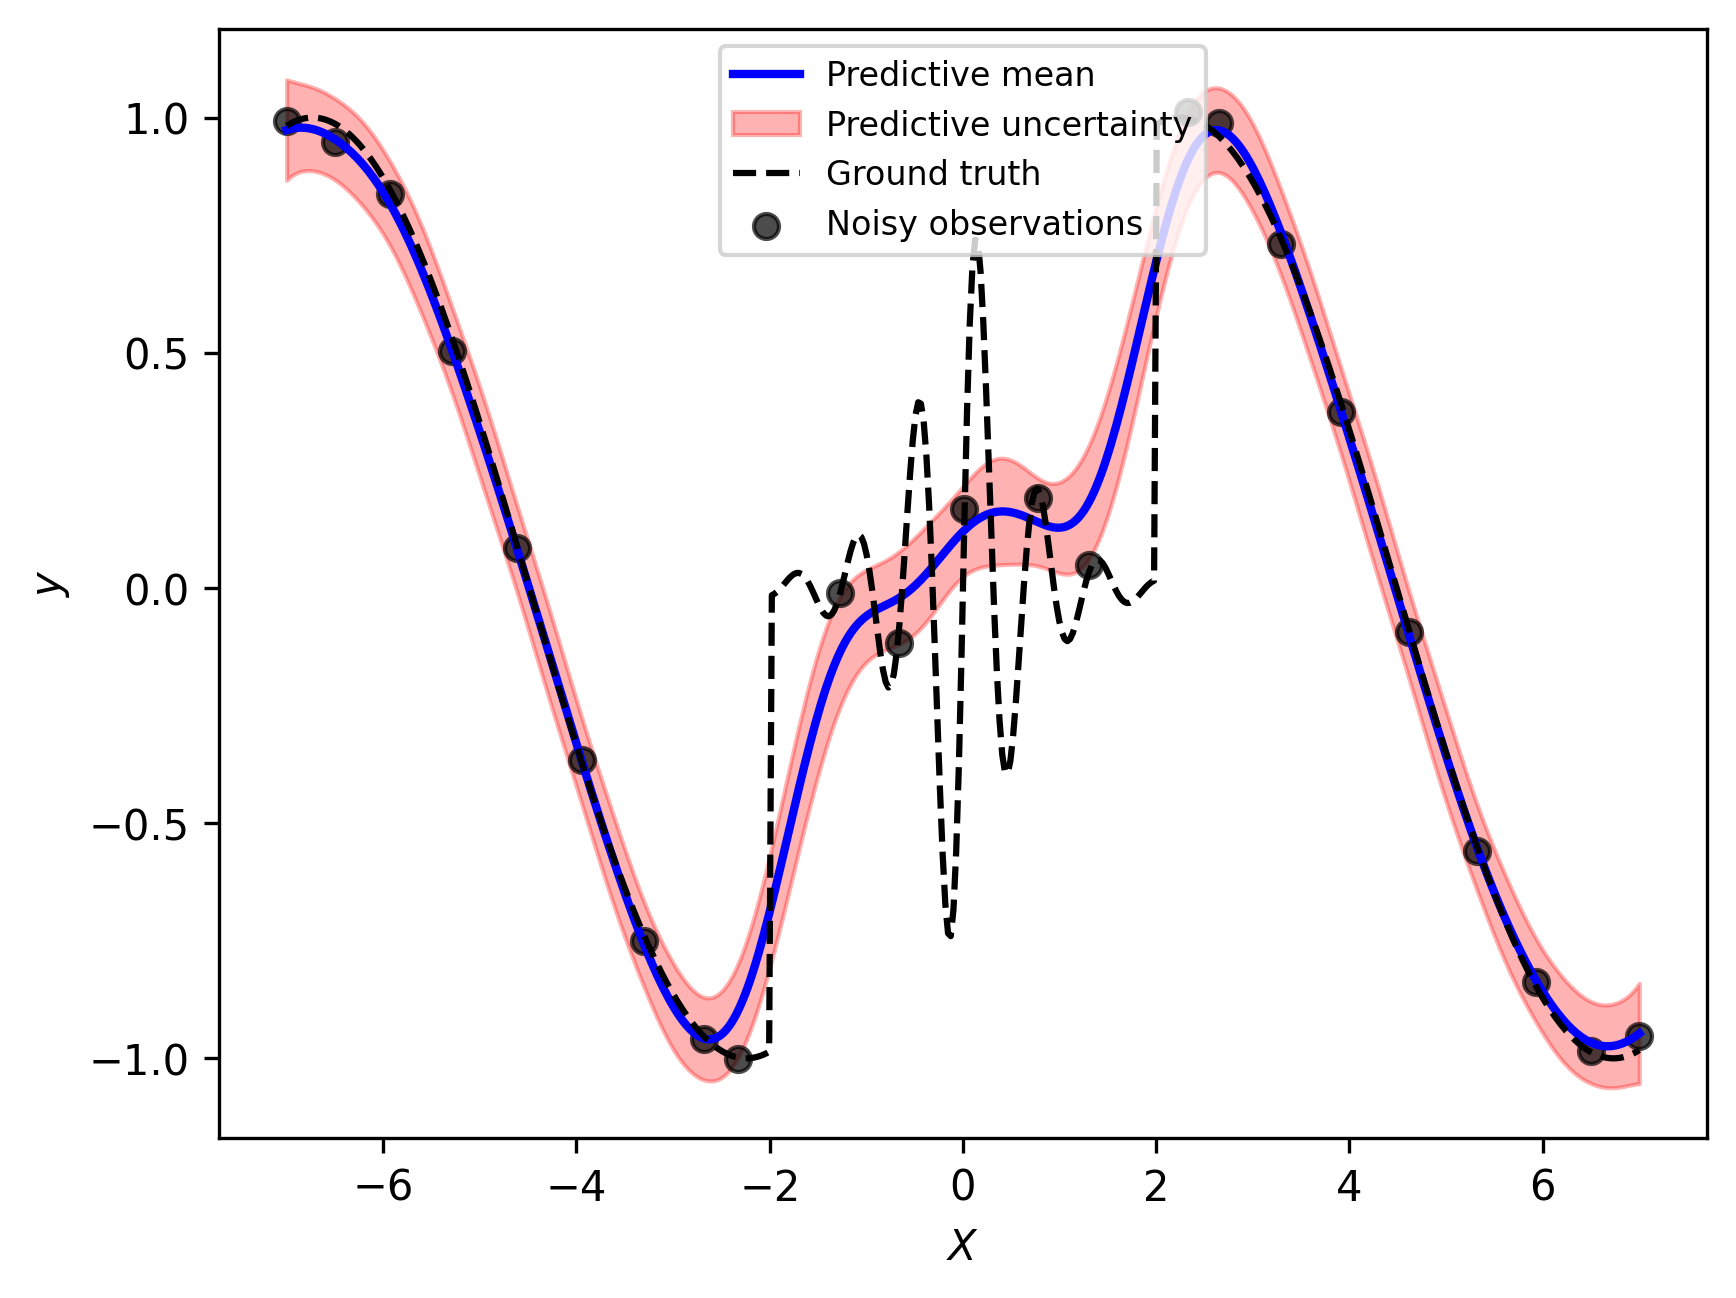

step 21


sample: 100%|██████████| 2000/2000 [00:01<00:00, 1768.82it/s, 7 steps of size 4.21e-01. acc. prob=0.94] 



                 mean       std    median      5.0%     95.0%     n_eff     r_hat
k_length[0]      1.73      0.47      1.68      1.06      2.51    469.12      1.01
    k_scale      0.67      0.39      0.56      0.19      1.13    523.97      1.00
      noise      0.02      0.02      0.01      0.00      0.04    705.43      1.00

step 22


sample: 100%|██████████| 2000/2000 [00:01<00:00, 1693.90it/s, 7 steps of size 4.47e-01. acc. prob=0.93] 



                 mean       std    median      5.0%     95.0%     n_eff     r_hat
k_length[0]      1.61      0.48      1.54      0.86      2.31    439.36      1.01
    k_scale      0.66      0.44      0.54      0.21      1.16    402.30      1.00
      noise      0.03      0.02      0.02      0.00      0.05    557.05      1.01

step 23


...


                 mean       std    median      5.0%     95.0%     n_eff     r_hat
k_length[0]      1.92      0.60      1.83      0.97      2.79    505.66      1.01
    k_scale      0.74      0.52      0.60      0.15      1.34    384.60      1.01
      noise      0.05      0.02      0.04      0.02      0.08    699.73      1.01

step 24


sample: 100%|██████████| 2000/2000 [00:01<00:00, 1657.05it/s, 7 steps of size 4.02e-01. acc. prob=0.95] 



                 mean       std    median      5.0%     95.0%     n_eff     r_hat
k_length[0]      1.86      0.57      1.80      0.98      2.73    472.42      1.00
    k_scale      0.72      0.53      0.58      0.19      1.22    355.29      1.00
      noise      0.04      0.02      0.04      0.02      0.07    778.80      1.00

step 25


sample: 100%|██████████| 2000/2000 [00:01<00:00, 1658.67it/s, 7 steps of size 4.16e-01. acc. prob=0.95]



                 mean       std    median      5.0%     95.0%     n_eff     r_hat
k_length[0]      1.84      0.56      1.79      0.94      2.71    335.99      1.01
    k_scale      0.73      0.57      0.58      0.16      1.30    316.71      1.00
      noise      0.04      0.02      0.03      0.01      0.06    745.52      1.00



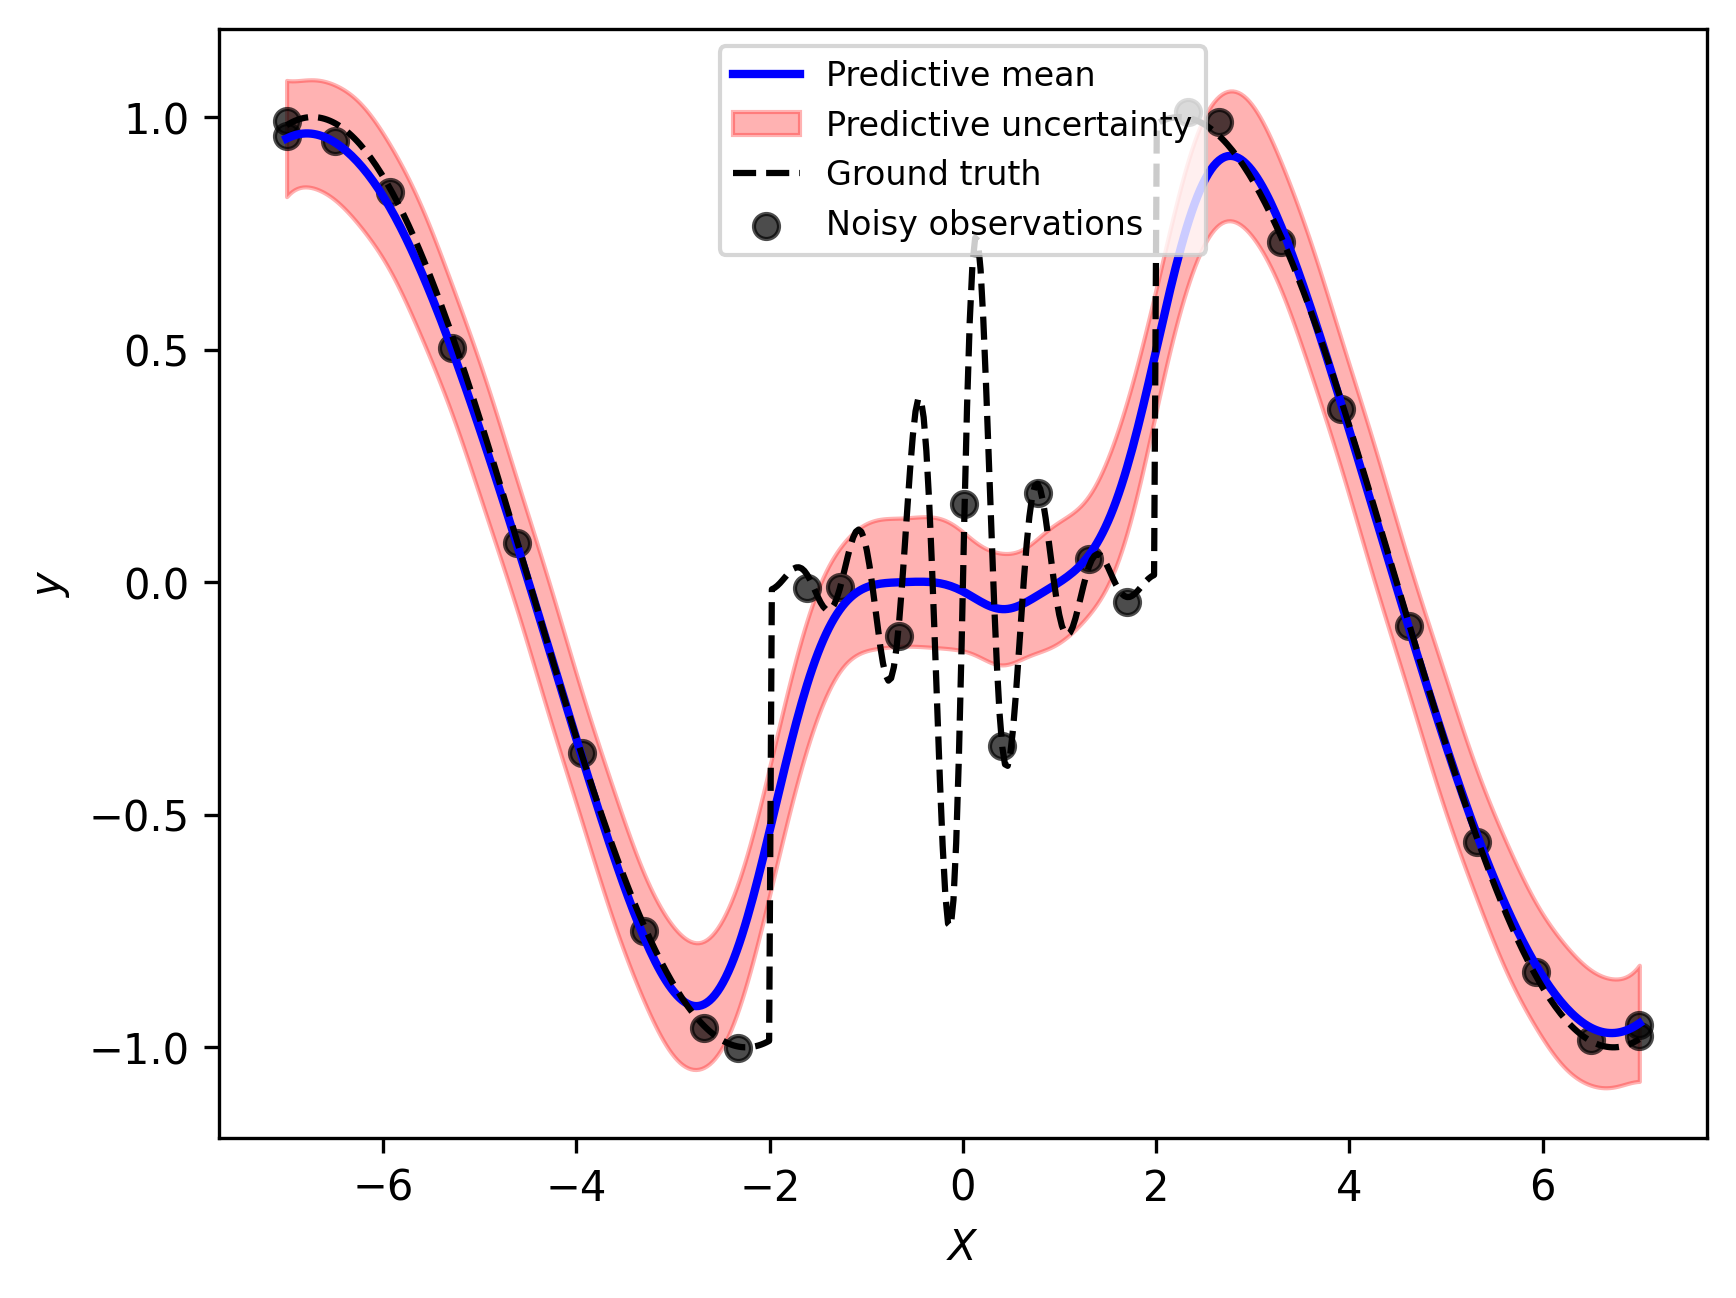

step 26


sample: 100%|██████████| 2000/2000 [00:01<00:00, 1684.53it/s, 7 steps of size 4.36e-01. acc. prob=0.94]



                 mean       std    median      5.0%     95.0%     n_eff     r_hat
k_length[0]      1.84      0.56      1.79      0.99      2.71    322.92      1.01
    k_scale      0.71      0.48      0.61      0.19      1.21    395.36      1.01
      noise      0.04      0.02      0.03      0.01      0.06    599.24      1.00

step 27


sample: 100%|██████████| 2000/2000 [00:01<00:00, 1356.54it/s, 7 steps of size 3.32e-01. acc. prob=0.94]



                 mean       std    median      5.0%     95.0%     n_eff     r_hat
k_length[0]      1.65      0.56      1.58      0.66      2.41    341.25      1.01
    k_scale      0.63      0.38      0.52      0.18      1.07    337.81      1.01
      noise      0.03      0.02      0.03      0.00      0.05    606.65      1.00

step 28


...


                 mean       std    median      5.0%     95.0%     n_eff     r_hat
k_length[0]      1.74      0.54      1.67      0.97      2.58    504.08      1.02
    k_scale      0.67      0.44      0.56      0.17      1.17    479.42      1.01
      noise      0.04      0.02      0.04      0.02      0.07    808.87      1.00

step 29


sample: 100%|██████████| 2000/2000 [00:15<00:00, 132.34it/s, 7 steps of size 5.23e-01. acc. prob=0.93] 



                 mean       std    median      5.0%     95.0%     n_eff     r_hat
k_length[0]      1.73      0.51      1.67      0.97      2.55    389.64      1.00
    k_scale      0.68      0.46      0.56      0.19      1.20    317.97      1.00
      noise      0.04      0.02      0.04      0.02      0.06    603.38      1.00

step 30


sample: 100%|██████████| 2000/2000 [00:08<00:00, 237.50it/s, 7 steps of size 5.44e-01. acc. prob=0.93] 



                 mean       std    median      5.0%     95.0%     n_eff     r_hat
k_length[0]      1.70      0.50      1.61      1.01      2.52    419.23      1.00
    k_scale      0.66      0.46      0.54      0.19      1.16    466.73      1.00
      noise      0.04      0.02      0.03      0.01      0.06    530.57      1.00



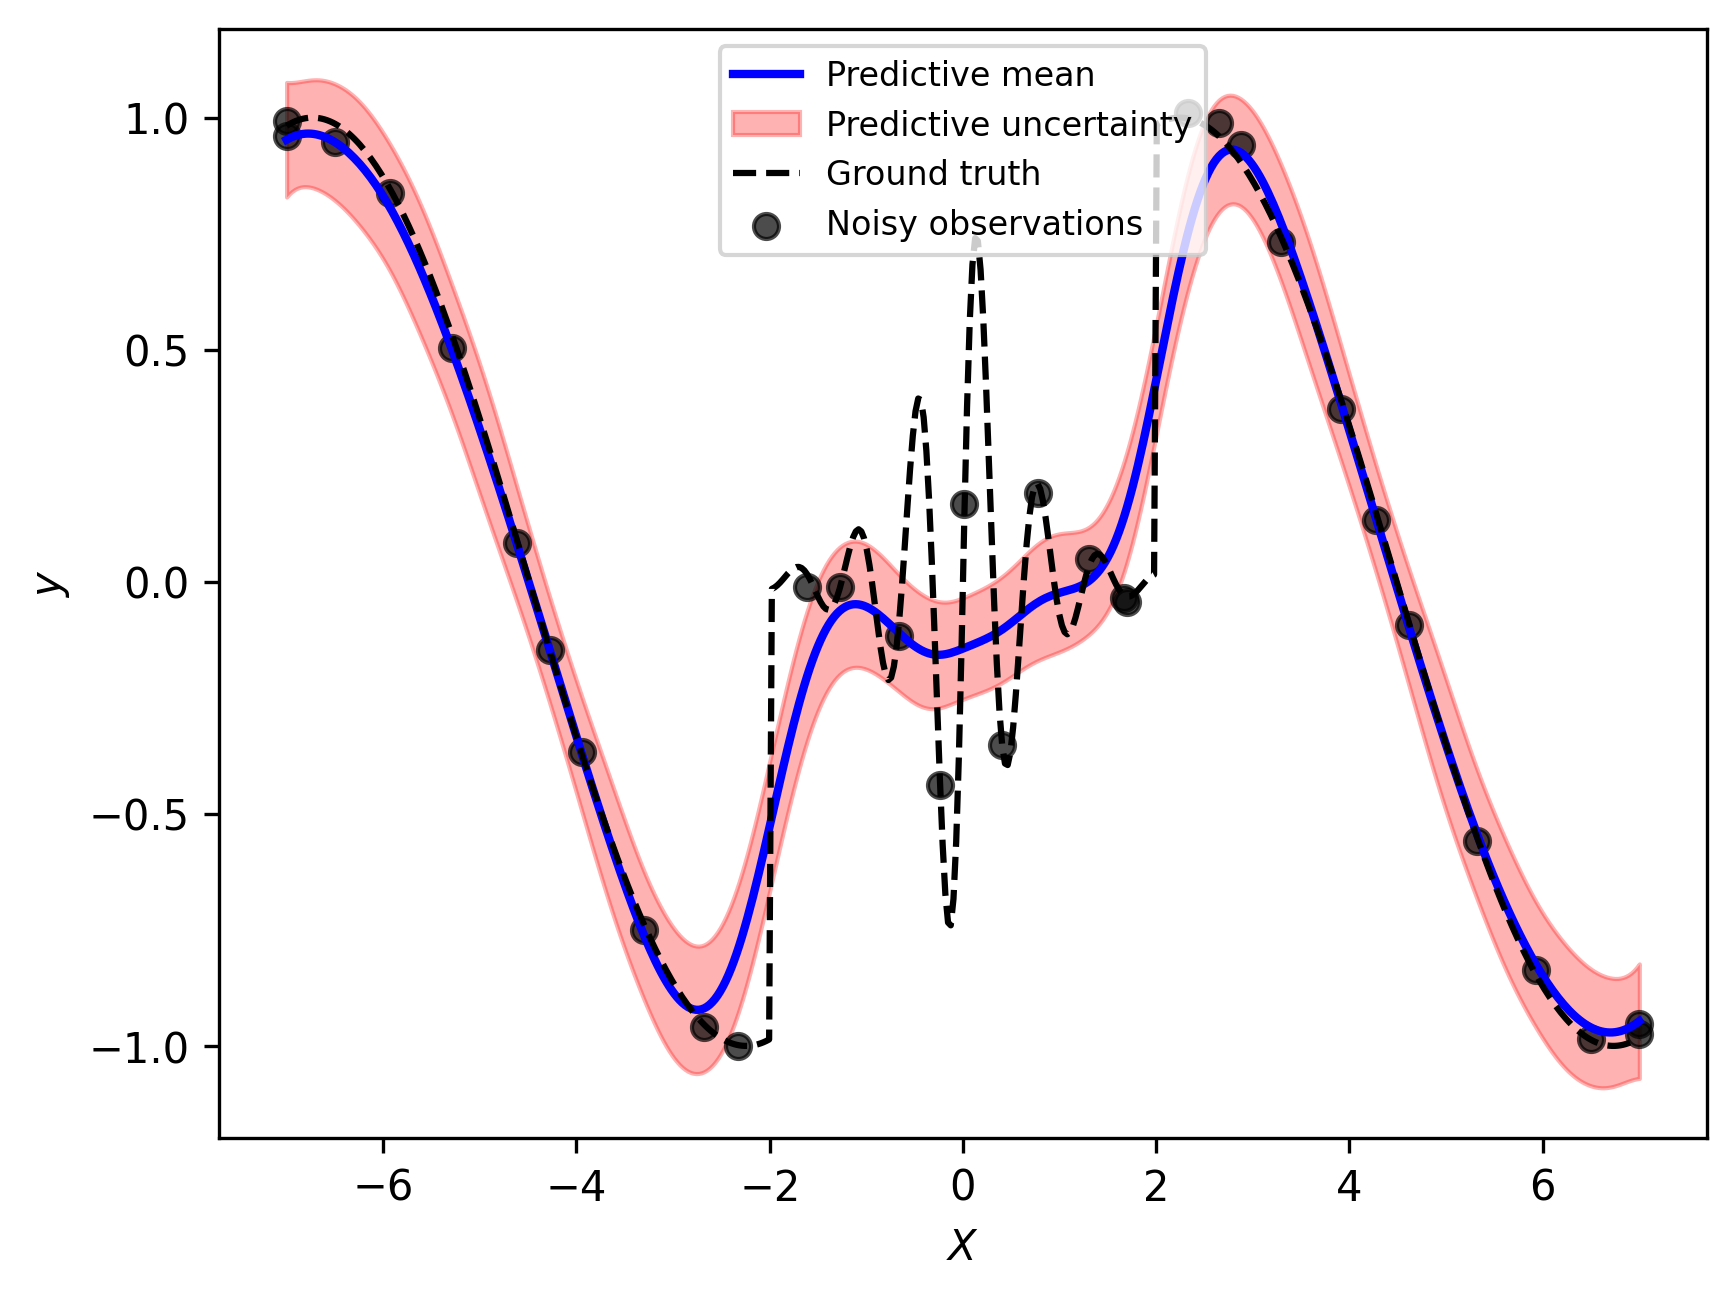

step 31


sample: 100%|██████████| 2000/2000 [00:09<00:00, 219.73it/s, 7 steps of size 5.27e-01. acc. prob=0.94] 



                 mean       std    median      5.0%     95.0%     n_eff     r_hat
k_length[0]      1.72      0.49      1.67      0.97      2.46    353.81      1.00
    k_scale      0.69      0.45      0.57      0.19      1.23    351.37      1.00
      noise      0.03      0.01      0.03      0.01      0.05    617.95      1.00

step 32


sample: 100%|██████████| 2000/2000 [00:15<00:00, 129.36it/s, 3 steps of size 4.39e-01. acc. prob=0.95] 



                 mean       std    median      5.0%     95.0%     n_eff     r_hat
k_length[0]      1.70      0.49      1.64      0.91      2.42    484.96      1.00
    k_scale      0.66      0.43      0.55      0.18      1.17    504.65      1.00
      noise      0.03      0.01      0.03      0.01      0.05    780.27      1.00

step 33


...


                 mean       std    median      5.0%     95.0%     n_eff     r_hat
k_length[0]      1.65      0.48      1.59      0.90      2.33    350.18      1.00
    k_scale      0.66      0.43      0.54      0.18      1.13    304.35      1.00
      noise      0.03      0.01      0.03      0.01      0.05    713.41      1.00

step 34


sample: 100%|██████████| 2000/2000 [00:03<00:00, 580.27it/s, 7 steps of size 4.84e-01. acc. prob=0.94] 



                 mean       std    median      5.0%     95.0%     n_eff     r_hat
k_length[0]      1.63      0.46      1.56      0.90      2.32    344.69      1.00
    k_scale      0.67      0.50      0.55      0.15      1.15    334.50      1.00
      noise      0.03      0.01      0.03      0.01      0.05    717.68      1.01

step 35


sample: 100%|██████████| 2000/2000 [00:04<00:00, 486.73it/s, 7 steps of size 3.84e-01. acc. prob=0.97] 



                 mean       std    median      5.0%     95.0%     n_eff     r_hat
k_length[0]      1.60      0.44      1.55      0.91      2.25    450.40      1.00
    k_scale      0.63      0.41      0.52      0.18      1.07    409.81      1.00
      noise      0.03      0.01      0.03      0.01      0.04    815.84      1.01



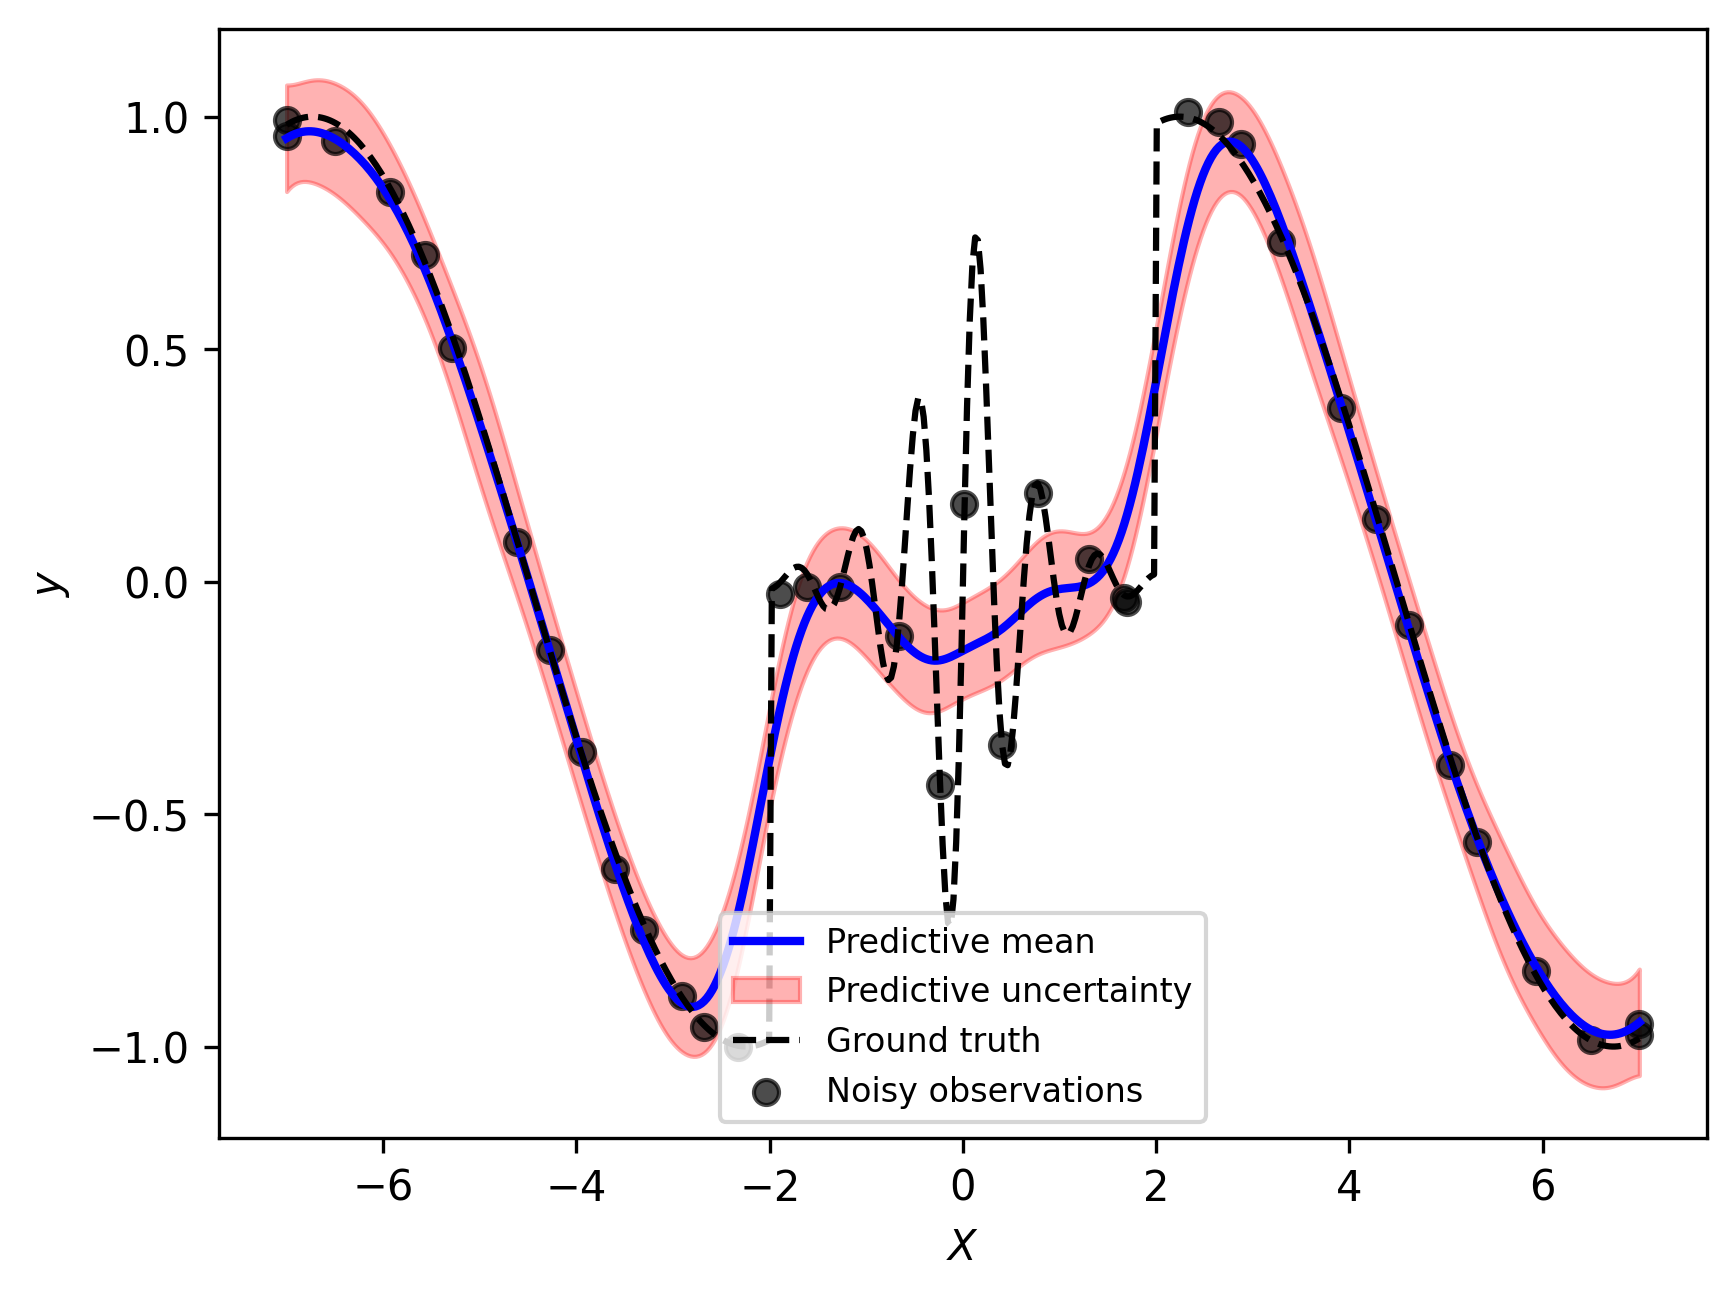

step 36


sample: 100%|██████████| 2000/2000 [00:03<00:00, 543.76it/s, 7 steps of size 5.19e-01. acc. prob=0.94] 



                 mean       std    median      5.0%     95.0%     n_eff     r_hat
k_length[0]      1.64      0.47      1.58      0.93      2.32    283.70      1.02
    k_scale      0.67      0.46      0.55      0.19      1.13    301.95      1.01
      noise      0.03      0.01      0.03      0.01      0.04    546.85      1.00

step 37


sample: 100%|██████████| 2000/2000 [00:04<00:00, 476.32it/s, 11 steps of size 5.40e-01. acc. prob=0.93]



                 mean       std    median      5.0%     95.0%     n_eff     r_hat
k_length[0]      1.62      0.44      1.55      0.95      2.31    332.99      1.01
    k_scale      0.65      0.43      0.54      0.17      1.10    367.14      1.01
      noise      0.03      0.01      0.03      0.01      0.04    707.50      1.00

step 38


...


                 mean       std    median      5.0%     95.0%     n_eff     r_hat
k_length[0]      1.59      0.43      1.55      0.92      2.22    407.06      1.00
    k_scale      0.64      0.41      0.54      0.18      1.08    301.37      1.00
      noise      0.03      0.01      0.03      0.01      0.04    691.63      1.00

step 39


sample: 100%|██████████| 2000/2000 [00:04<00:00, 486.97it/s, 7 steps of size 4.52e-01. acc. prob=0.95] 



                 mean       std    median      5.0%     95.0%     n_eff     r_hat
k_length[0]      1.58      0.42      1.53      0.91      2.17    477.74      1.01
    k_scale      0.63      0.40      0.53      0.19      1.09    422.35      1.01
      noise      0.03      0.01      0.02      0.01      0.04    627.06      1.00

step 40


sample: 100%|██████████| 2000/2000 [00:04<00:00, 483.42it/s, 7 steps of size 4.37e-01. acc. prob=0.95] 



                 mean       std    median      5.0%     95.0%     n_eff     r_hat
k_length[0]      1.60      0.42      1.54      0.93      2.18    445.22      1.00
    k_scale      0.65      0.41      0.53      0.19      1.15    383.11      1.00
      noise      0.02      0.01      0.02      0.01      0.04    679.26      1.00



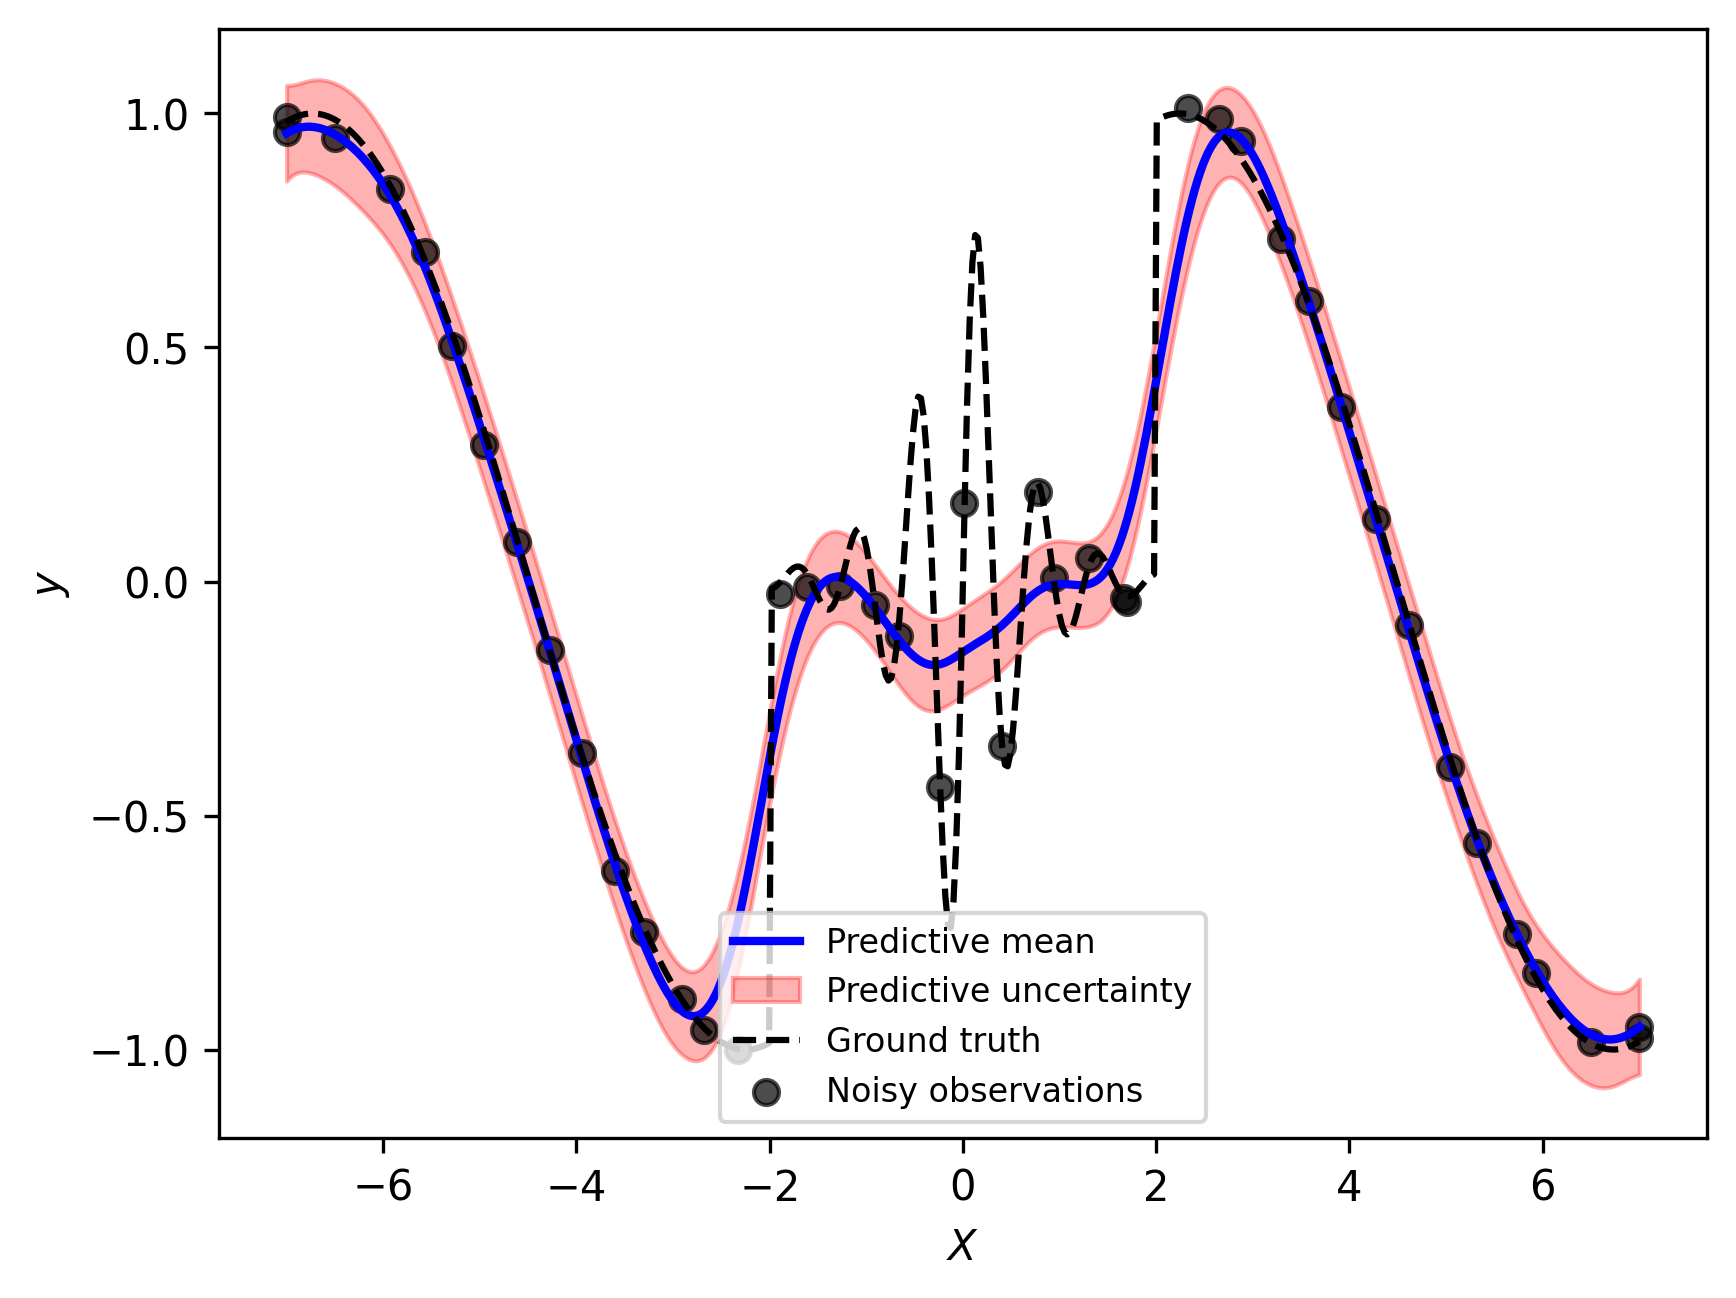

In [3]:
exploration_steps = 40
num_init_points = 4

np.random.seed(42)
X_measured = np.linspace(x_start, x_stop, num_init_points)
y_measured = measure(X_measured)

for step in range(exploration_steps):
    print('step {}'.format(step + 1))
    model = nb.GP(kernel=nb.kernels.MaternKernel)
    model.fit(X_measured, y_measured, num_warmup=1000, num_samples=1000)
    posterior_mean, posterior_var = model.predict(X_domain)
    next_point_idx = posterior_var.argmax()
    X_next = X_domain[next_point_idx][None]
    y_next = measure(X_next)

    if step in (0, exploration_steps - 1) or (step + 1) % 5 == 0:
        _, ax = plt.subplots(dpi=300)
        ax.set_xlabel("$X$")
        ax.set_ylabel("$y$")
        ax.plot(X_domain, posterior_mean, lw=2.0,  c='blue', label='Predictive mean')
        ax.fill_between(X_domain,
                        posterior_mean - np.sqrt(posterior_var),
                        posterior_mean + np.sqrt(posterior_var),
                        color='r', alpha=0.3, label="Predictive uncertainty")
        ax.plot(X_domain, y_true, '--', c='k', label='Ground truth')
        ax.scatter(X_measured, y_measured, c='k', label="Noisy observations", alpha=0.7)
        ax.legend(loc='best', fontsize=8)
        plt.show()

    X_measured = np.append(X_measured, X_next)
    y_measured = np.append(y_measured, y_next)

Compute MSE and NLPD scores:

In [4]:
mse_gp = nb.utils.mse(posterior_mean, y_true)
nlpd_gp = nb.utils.nlpd(y_true, posterior_mean, posterior_var)

## FBNN-based active learning

A fully Bayesian Neural Network treats the weights in a neural network as probabilistic distributions and utilizes the No-U-Turn Sampler to sample directly from the posterior distribution. This approach allows the FBNN to account for all plausible weight configurations, enabling it to make probabilistic predictions.

step 1


sample: 100%|██████████| 2000/2000 [00:08<00:00, 239.76it/s, 255 steps of size 1.66e-02. acc. prob=0.55]


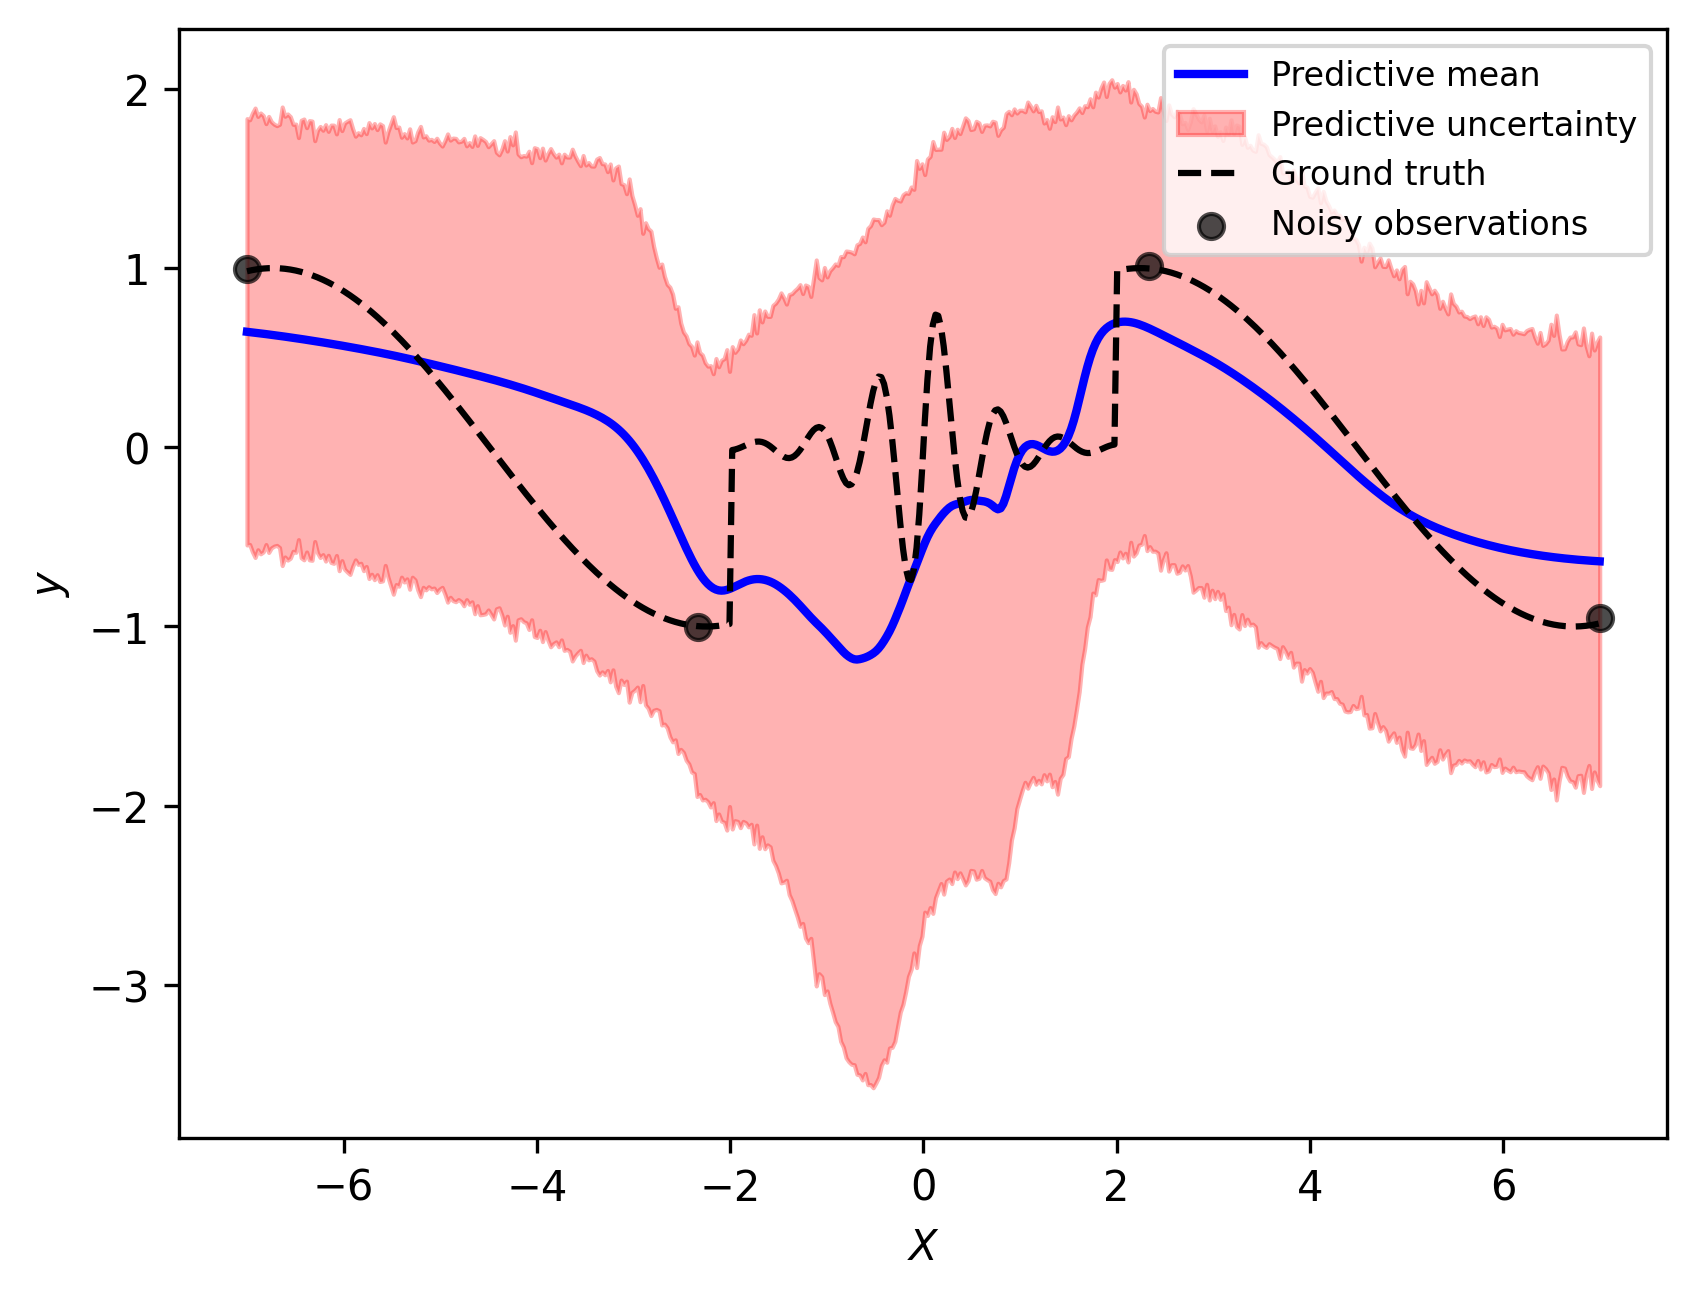

step 2


sample: 100%|██████████| 2000/2000 [00:10<00:00, 191.99it/s, 511 steps of size 9.88e-03. acc. prob=0.83]


step 3


sample: 100%|██████████| 2000/2000 [00:08<00:00, 235.14it/s, 255 steps of size 1.29e-02. acc. prob=0.85]


step 4


sample: 100%|██████████| 2000/2000 [00:12<00:00, 165.33it/s, 511 steps of size 1.13e-02. acc. prob=0.76]


step 5


sample: 100%|██████████| 2000/2000 [00:11<00:00, 168.45it/s, 511 steps of size 9.46e-03. acc. prob=0.82]


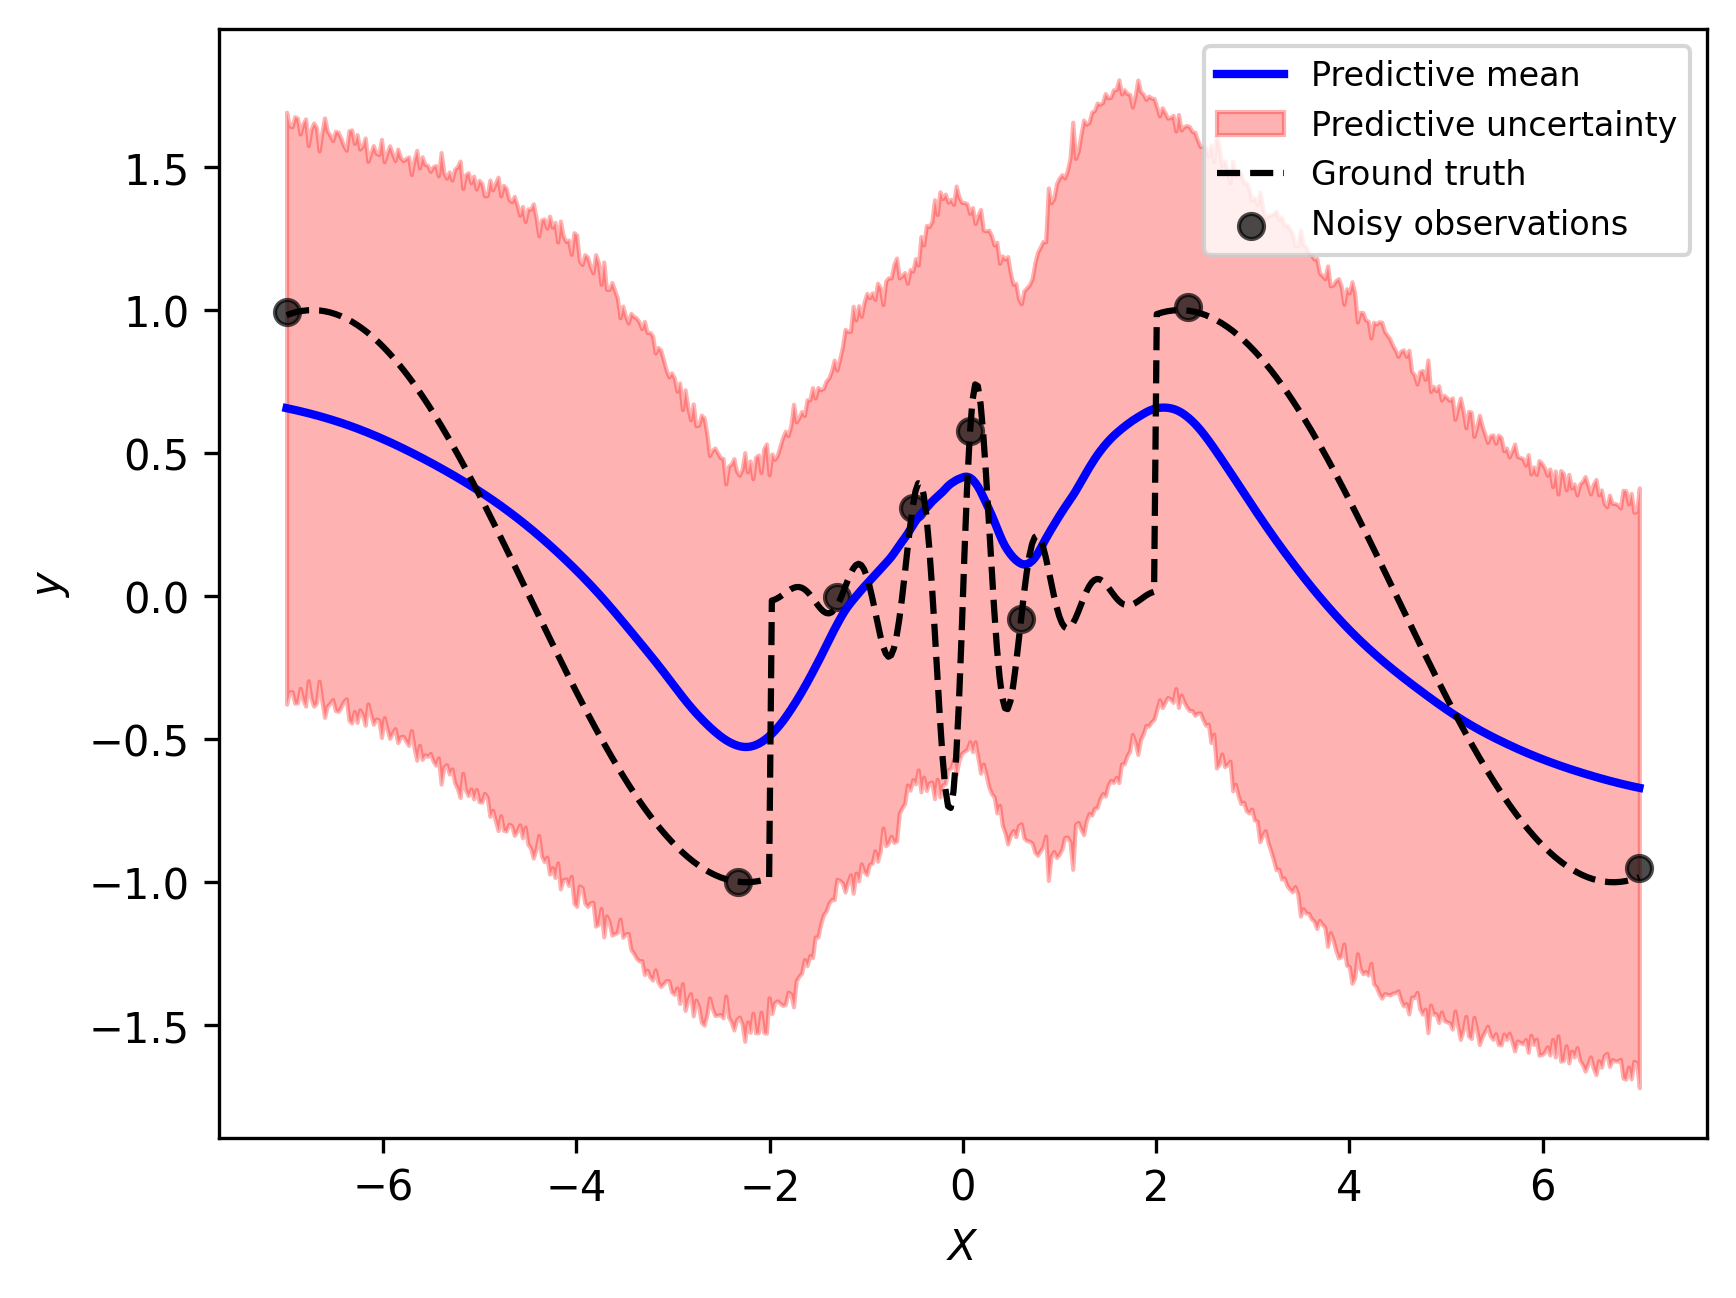

step 6


sample: 100%|██████████| 2000/2000 [00:12<00:00, 165.36it/s, 511 steps of size 7.36e-03. acc. prob=0.89]


step 7


sample: 100%|██████████| 2000/2000 [00:09<00:00, 204.66it/s, 255 steps of size 1.30e-02. acc. prob=0.73]


step 8


sample: 100%|██████████| 2000/2000 [00:13<00:00, 143.75it/s, 511 steps of size 9.64e-03. acc. prob=0.76]


step 9


sample: 100%|██████████| 2000/2000 [00:08<00:00, 225.95it/s, 255 steps of size 1.41e-02. acc. prob=0.69]


step 10


sample: 100%|██████████| 2000/2000 [00:12<00:00, 163.91it/s, 511 steps of size 8.81e-03. acc. prob=0.92]


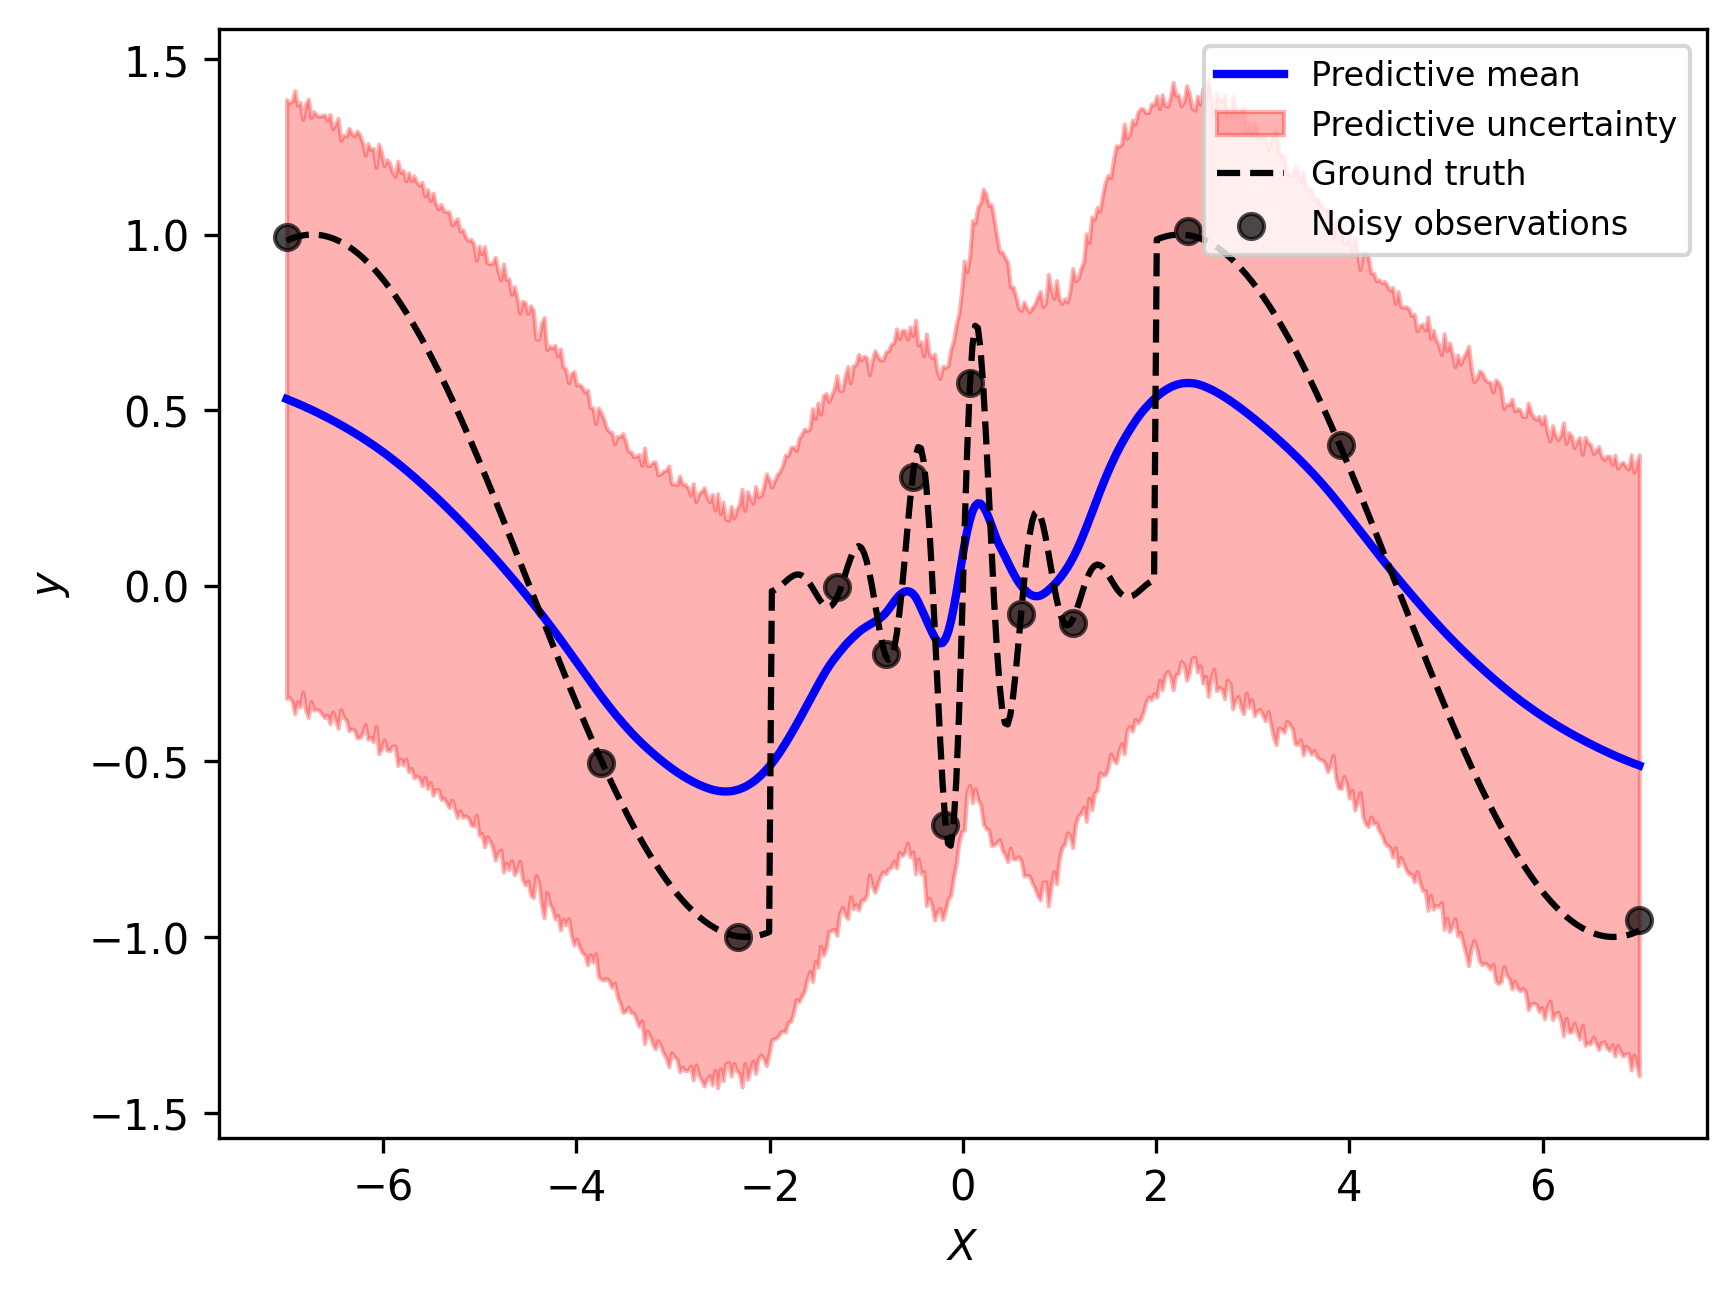

step 11


sample: 100%|██████████| 2000/2000 [00:13<00:00, 150.25it/s, 511 steps of size 1.05e-02. acc. prob=0.81]


step 12


sample: 100%|██████████| 2000/2000 [00:10<00:00, 197.50it/s, 255 steps of size 1.31e-02. acc. prob=0.77]


step 13


sample: 100%|██████████| 2000/2000 [00:13<00:00, 143.68it/s, 511 steps of size 8.98e-03. acc. prob=0.81]


step 14


sample: 100%|██████████| 2000/2000 [00:14<00:00, 140.34it/s, 511 steps of size 9.59e-03. acc. prob=0.57]


step 15


sample: 100%|██████████| 2000/2000 [00:19<00:00, 100.14it/s, 1023 steps of size 4.94e-03. acc. prob=0.81]


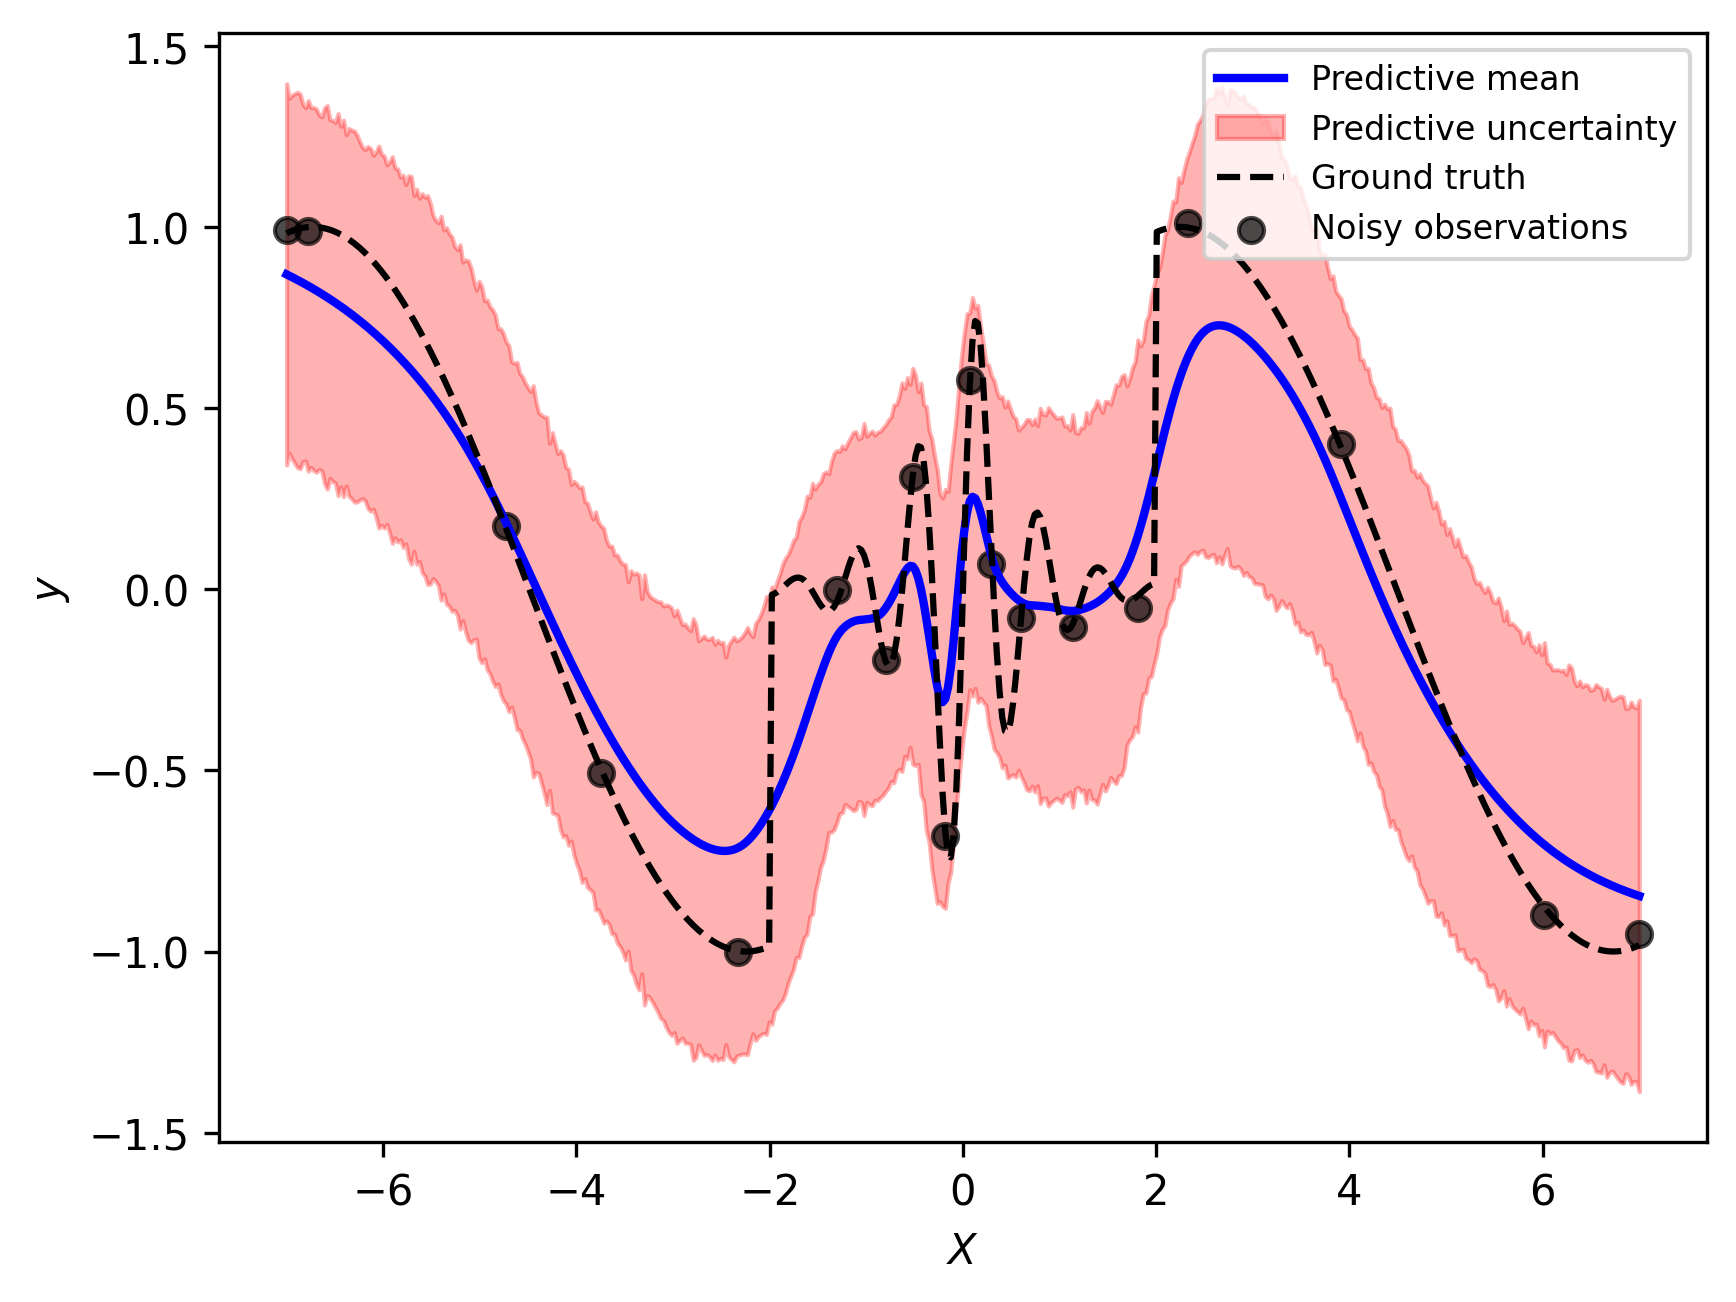

step 16


sample: 100%|██████████| 2000/2000 [00:21<00:00, 92.41it/s, 1023 steps of size 2.74e-03. acc. prob=0.86] 


step 17


sample: 100%|██████████| 2000/2000 [00:21<00:00, 91.31it/s, 1023 steps of size 2.18e-03. acc. prob=0.93]


step 18


sample: 100%|██████████| 2000/2000 [00:22<00:00, 87.53it/s, 1023 steps of size 1.91e-04. acc. prob=0.99]


step 19


sample: 100%|██████████| 2000/2000 [00:22<00:00, 90.35it/s, 1023 steps of size 3.71e-03. acc. prob=0.88]


step 20


sample: 100%|██████████| 2000/2000 [00:25<00:00, 78.43it/s, 1023 steps of size 2.43e-03. acc. prob=0.85]


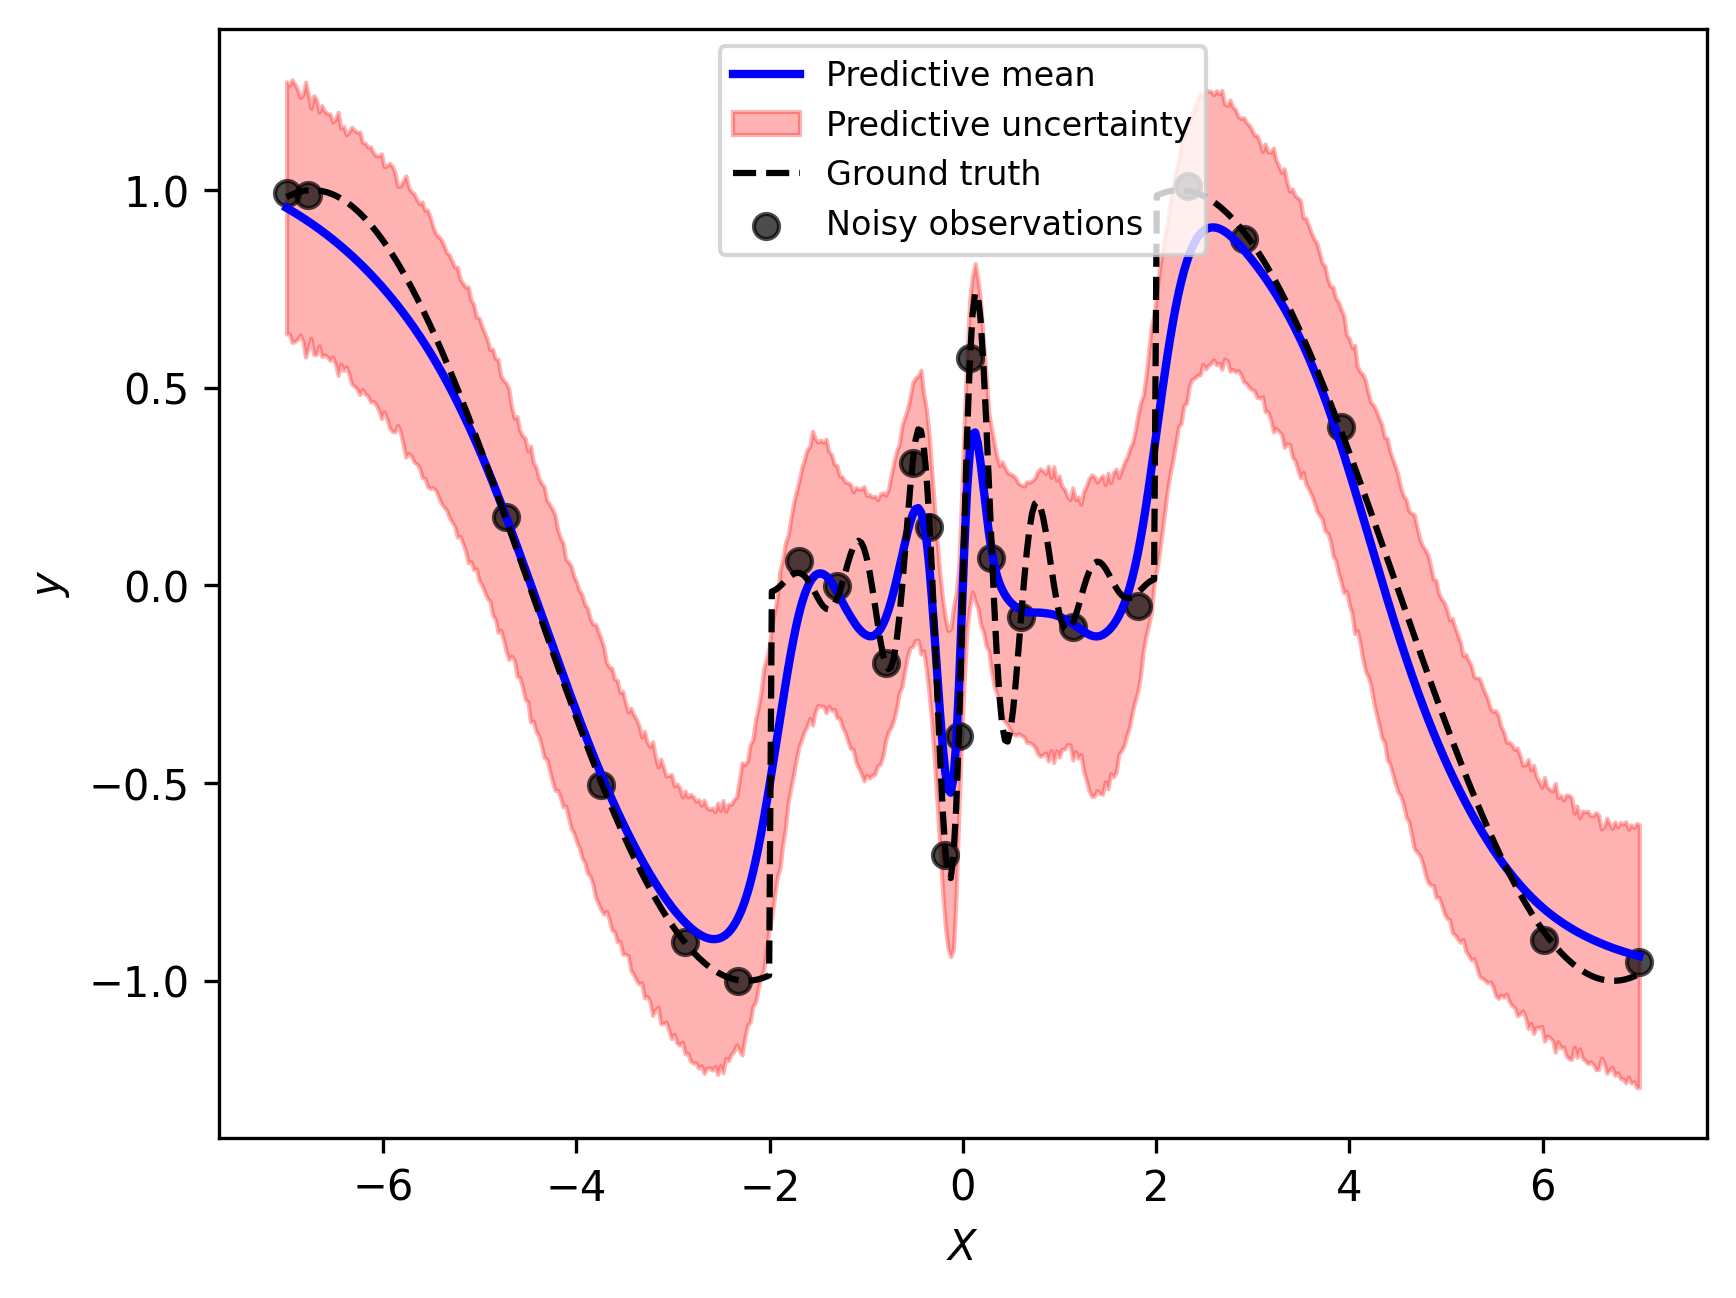

step 21


sample: 100%|██████████| 2000/2000 [00:25<00:00, 79.81it/s, 1023 steps of size 1.03e-04. acc. prob=0.97]


step 22


sample: 100%|██████████| 2000/2000 [00:26<00:00, 74.68it/s, 1023 steps of size 1.48e-03. acc. prob=0.89]


step 23


sample: 100%|██████████| 2000/2000 [00:25<00:00, 79.05it/s, 1023 steps of size 1.34e-03. acc. prob=0.91]


step 24


sample: 100%|██████████| 2000/2000 [00:26<00:00, 76.48it/s, 652 steps of size 1.41e-03. acc. prob=0.87] 


step 25


sample: 100%|██████████| 2000/2000 [00:26<00:00, 76.64it/s, 1023 steps of size 1.08e-03. acc. prob=0.92]


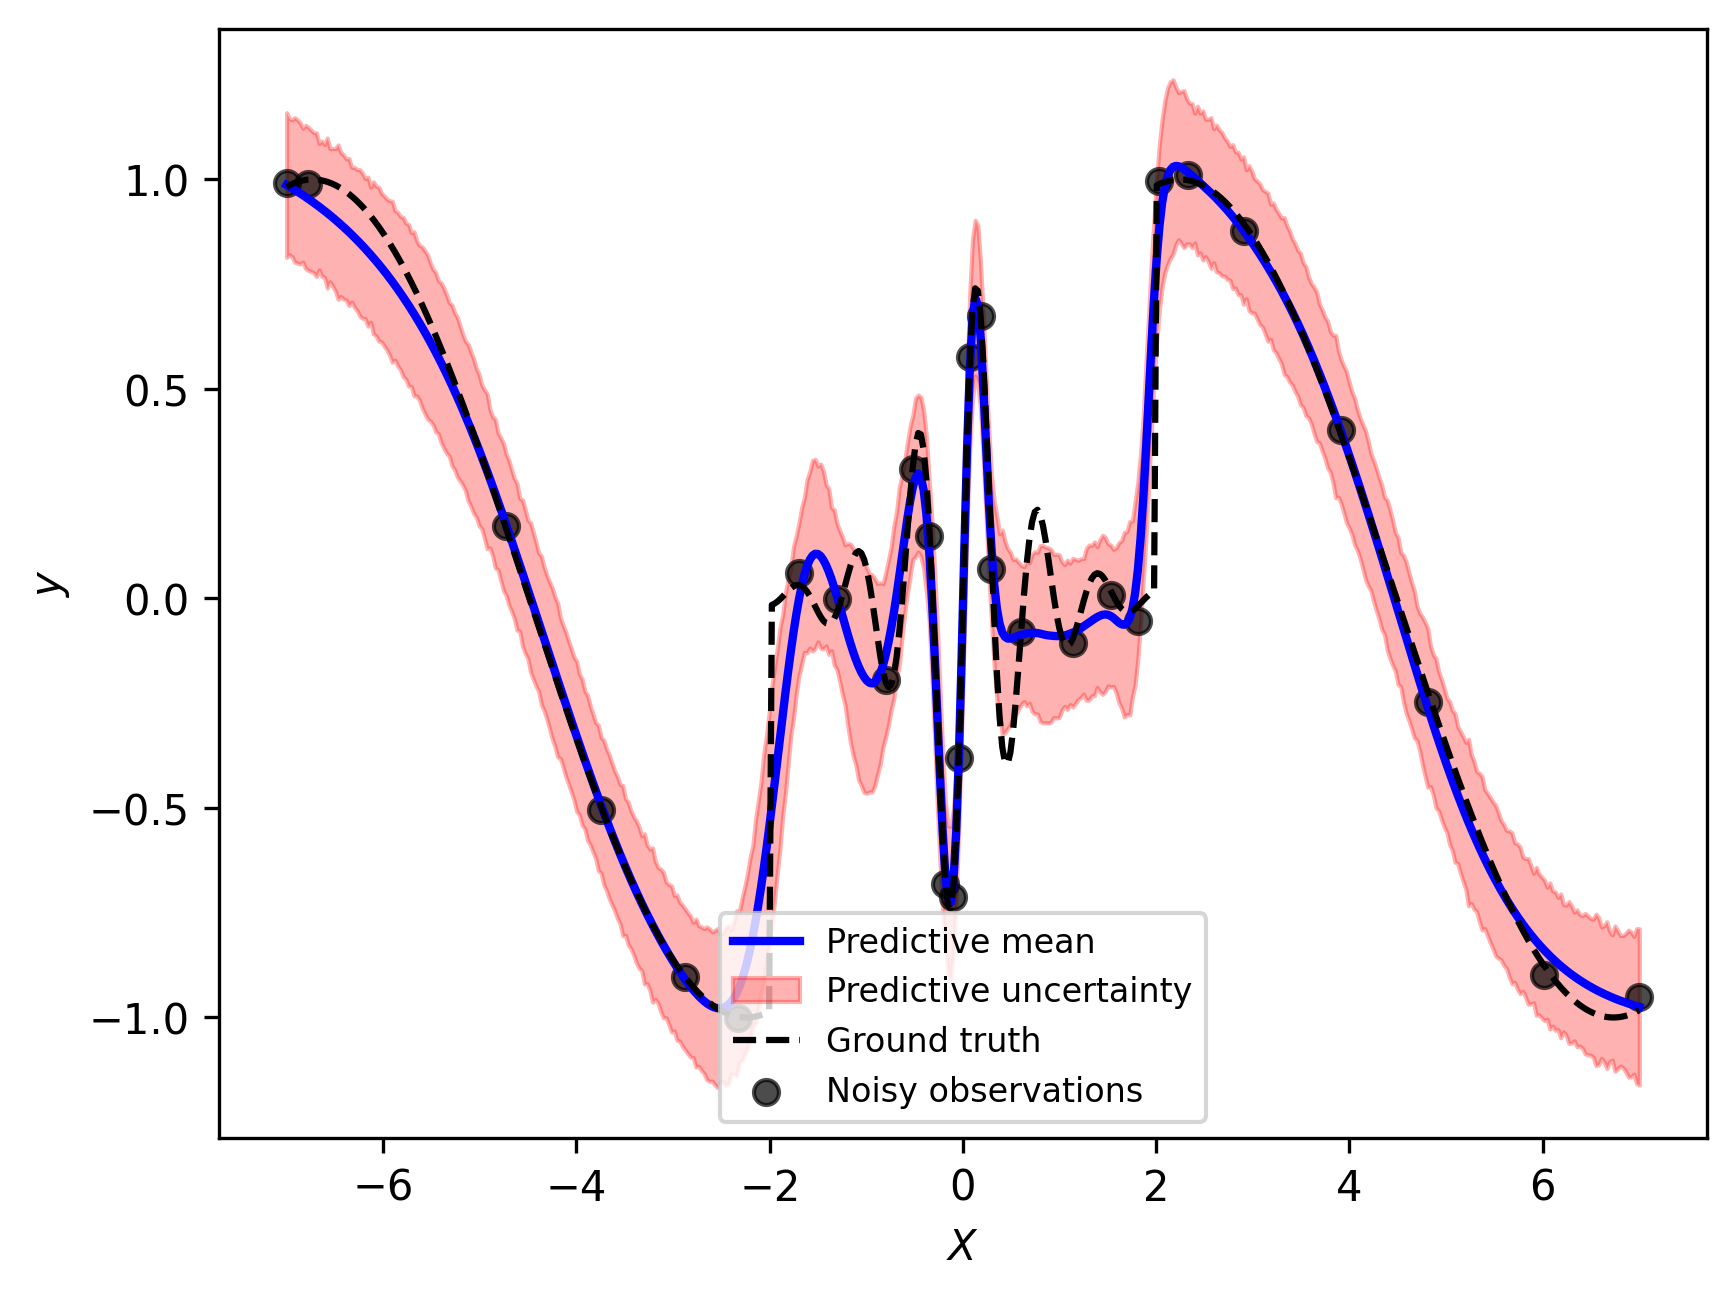

step 26


sample: 100%|██████████| 2000/2000 [00:23<00:00, 85.98it/s, 1023 steps of size 2.06e-03. acc. prob=0.65] 


step 27


sample: 100%|██████████| 2000/2000 [00:26<00:00, 75.73it/s, 1023 steps of size 2.19e-03. acc. prob=0.85]


step 28


sample: 100%|██████████| 2000/2000 [00:27<00:00, 73.06it/s, 1023 steps of size 1.89e-03. acc. prob=0.92]


step 29


sample: 100%|██████████| 2000/2000 [00:26<00:00, 74.51it/s, 1023 steps of size 2.02e-03. acc. prob=0.91]


step 30


sample: 100%|██████████| 2000/2000 [00:30<00:00, 65.36it/s, 1023 steps of size 1.52e-03. acc. prob=0.94]


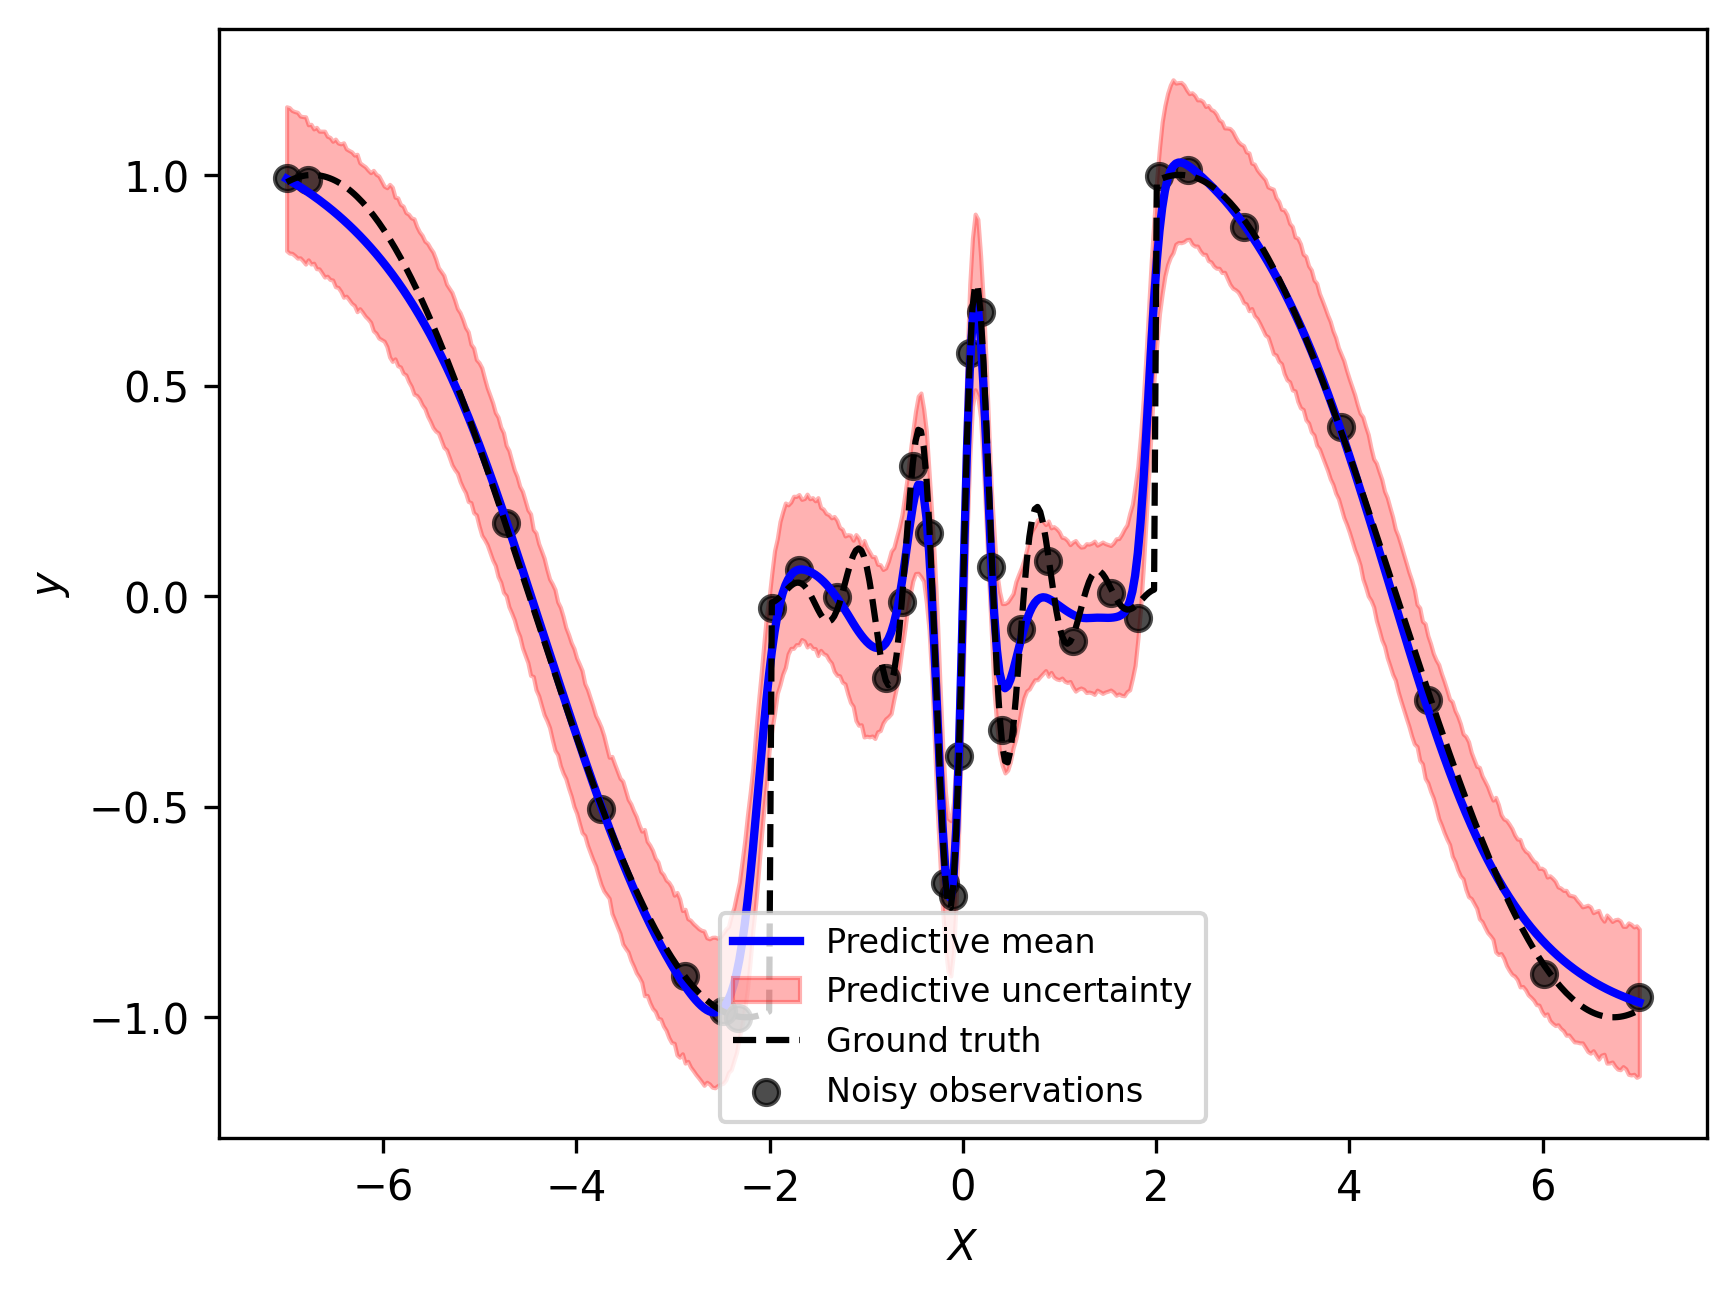

step 31


sample: 100%|██████████| 2000/2000 [00:31<00:00, 63.42it/s, 1023 steps of size 2.29e-03. acc. prob=0.88]


step 32


sample: 100%|██████████| 2000/2000 [00:31<00:00, 64.36it/s, 1023 steps of size 2.22e-03. acc. prob=0.81]


step 33


sample: 100%|██████████| 2000/2000 [00:30<00:00, 64.96it/s, 1023 steps of size 1.98e-03. acc. prob=0.85]


step 34


sample: 100%|██████████| 2000/2000 [00:30<00:00, 66.26it/s, 1023 steps of size 2.09e-03. acc. prob=0.74]


step 35


sample: 100%|██████████| 2000/2000 [00:29<00:00, 66.81it/s, 1023 steps of size 2.01e-03. acc. prob=0.72]


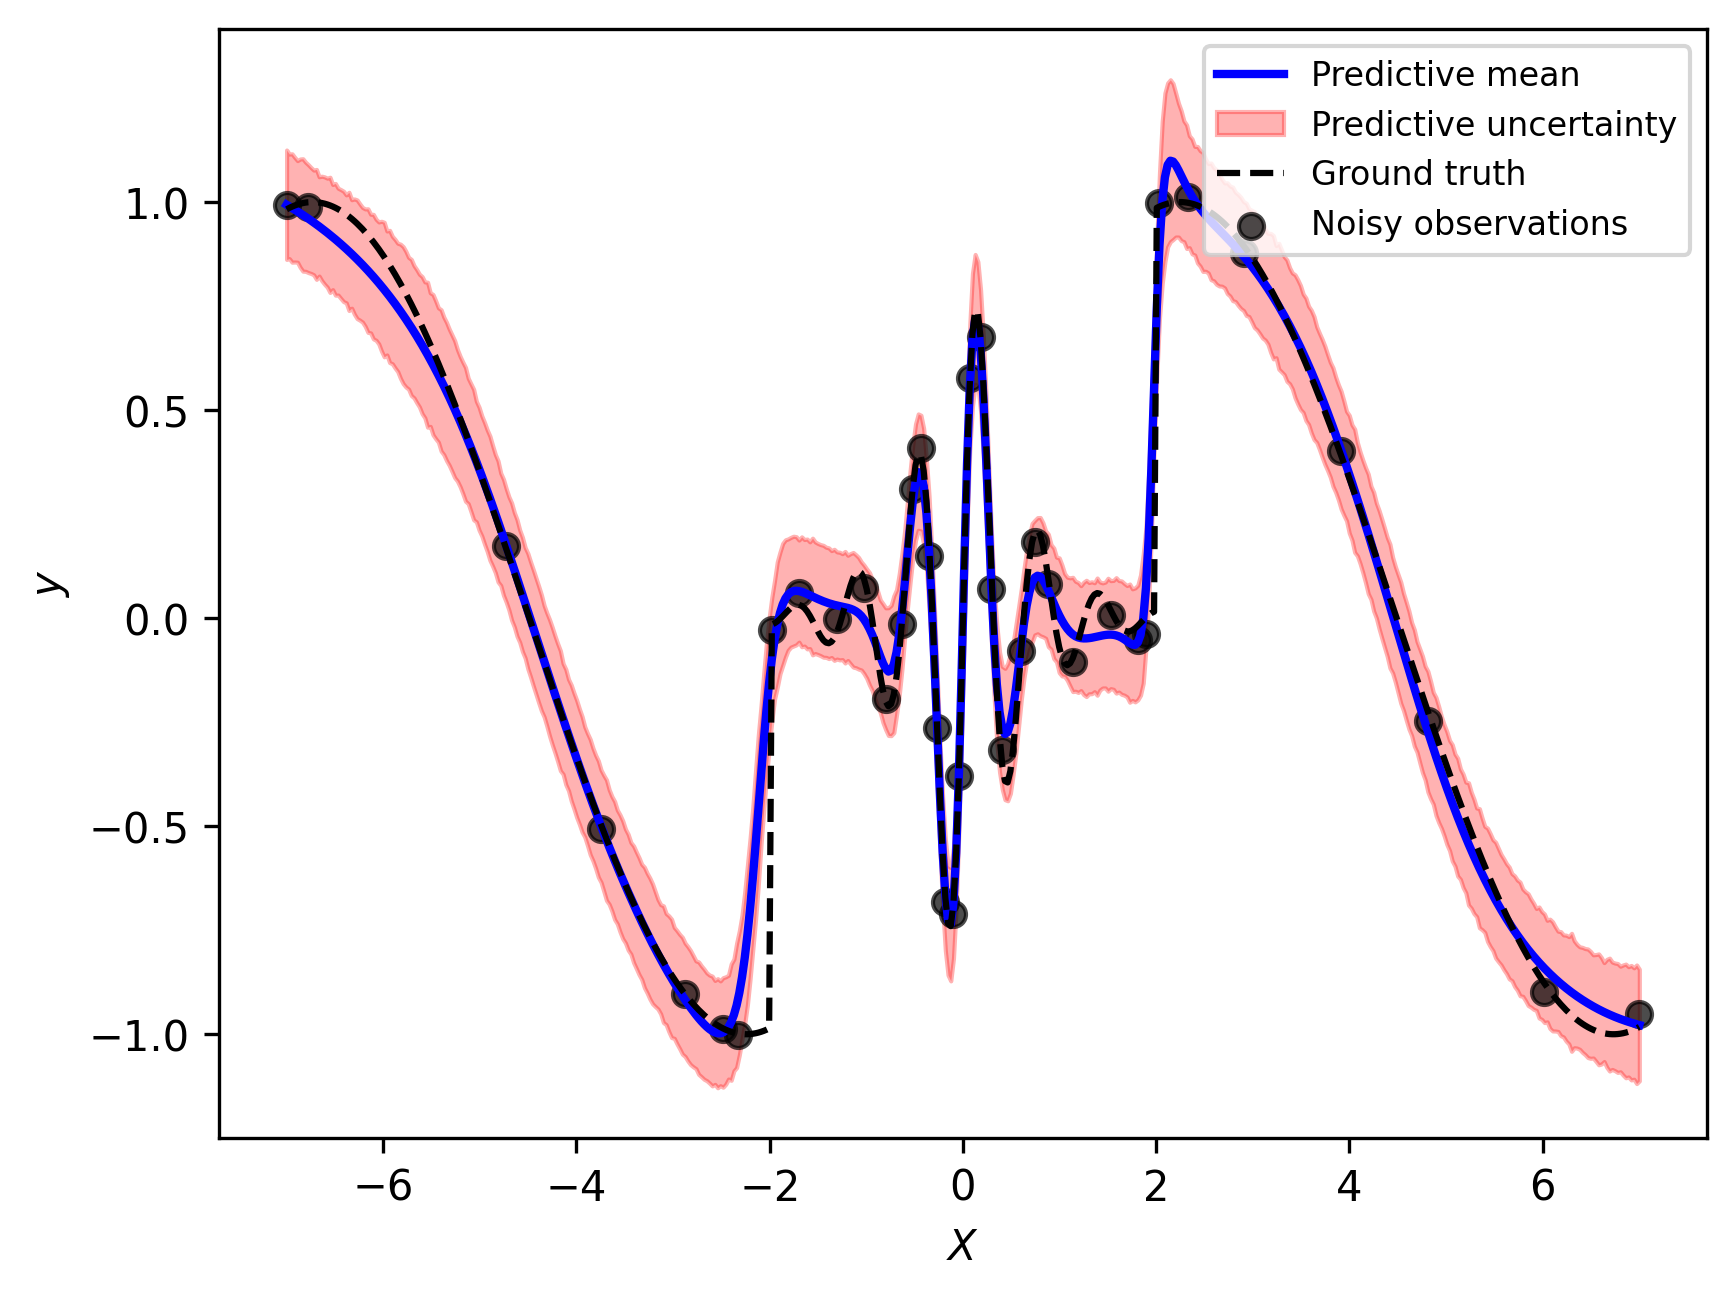

step 36


sample: 100%|██████████| 2000/2000 [00:31<00:00, 62.84it/s, 1023 steps of size 1.64e-03. acc. prob=0.89]


step 37


sample: 100%|██████████| 2000/2000 [00:32<00:00, 62.08it/s, 1023 steps of size 1.83e-03. acc. prob=0.93]


step 38


sample: 100%|██████████| 2000/2000 [00:32<00:00, 61.51it/s, 1023 steps of size 1.24e-03. acc. prob=0.95]


step 39


sample: 100%|██████████| 2000/2000 [00:31<00:00, 62.56it/s, 1023 steps of size 1.67e-03. acc. prob=0.89]


step 40


sample: 100%|██████████| 2000/2000 [00:31<00:00, 62.59it/s, 1023 steps of size 1.70e-03. acc. prob=0.77]


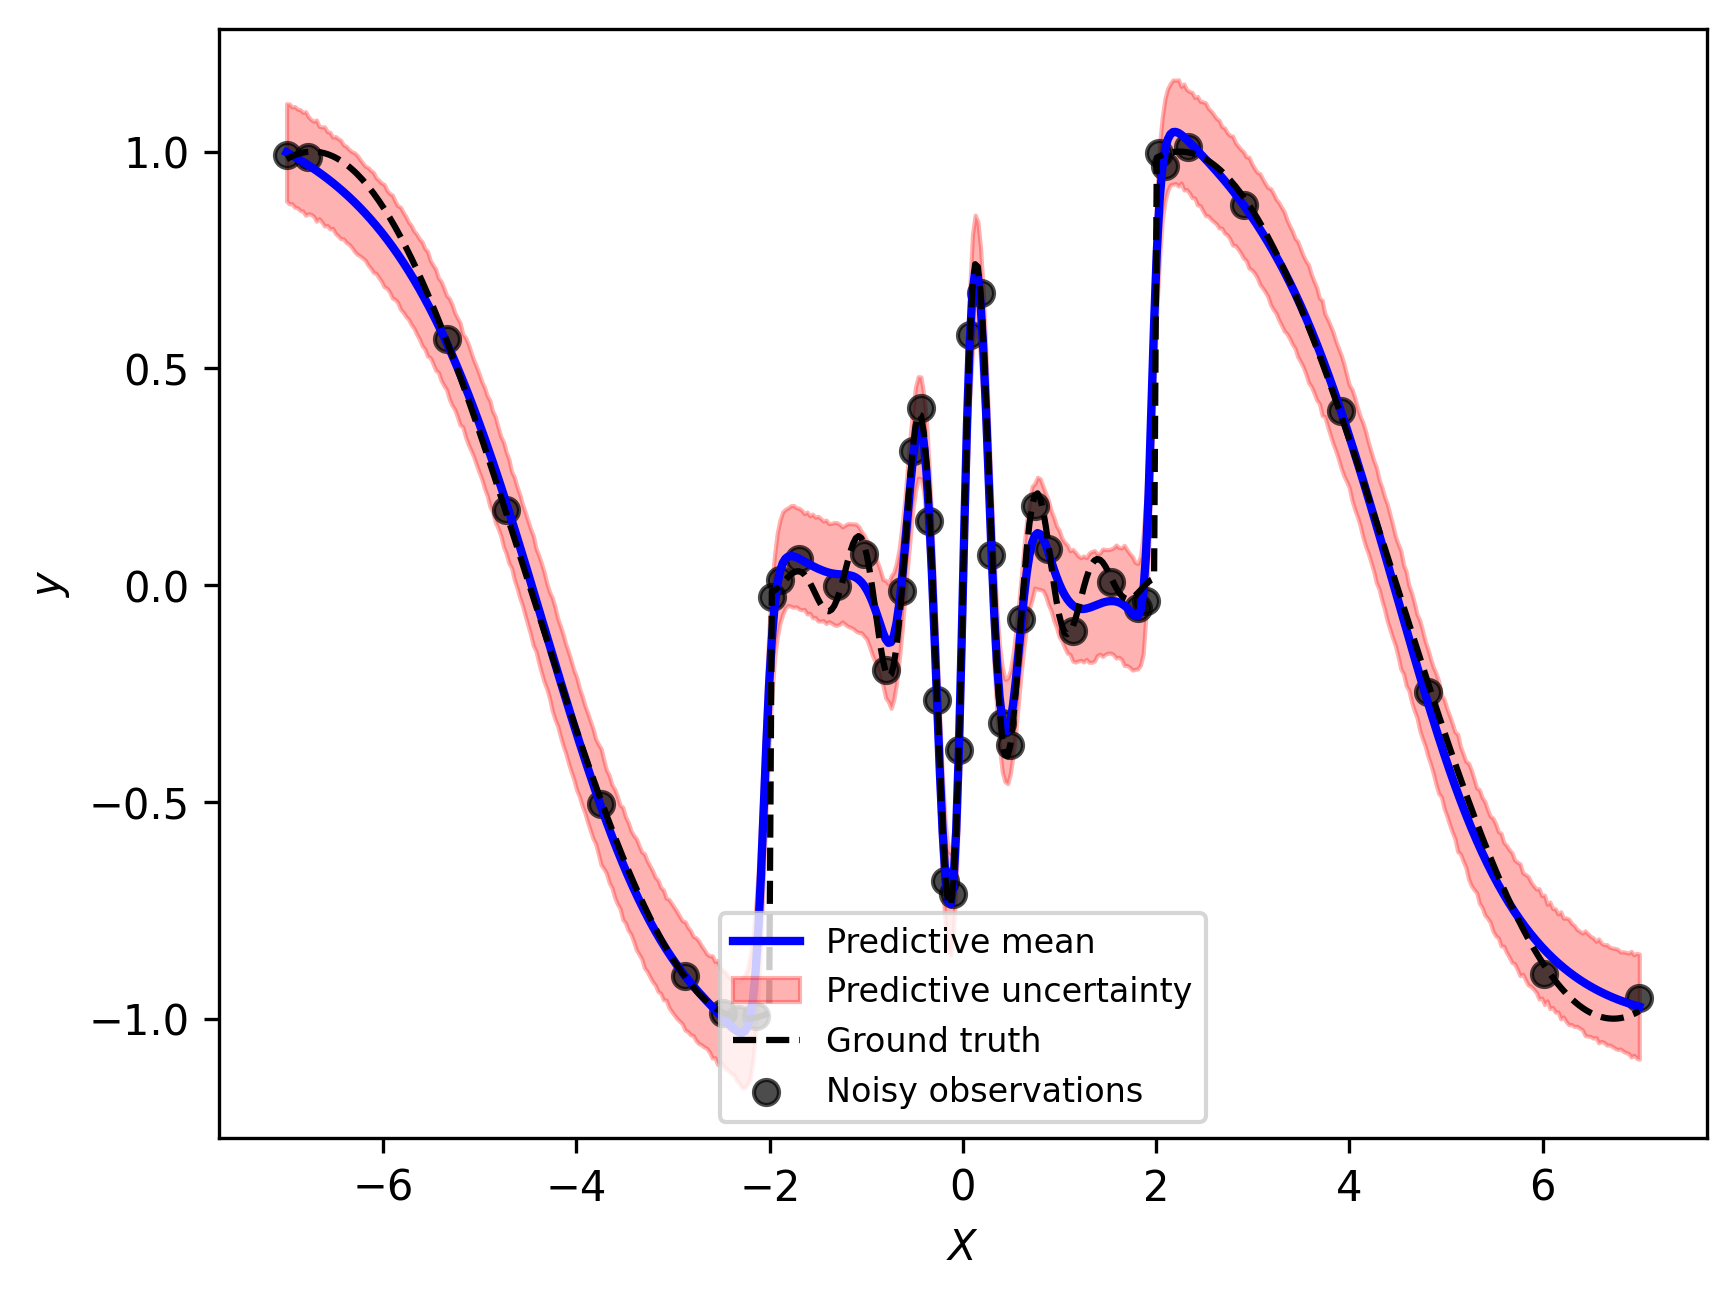

In [5]:
exploration_steps = 40
num_init_points = 4

np.random.seed(42)
X_measured = np.linspace(x_start, x_stop, num_init_points)
y_measured = measure(X_measured)

for step in range(exploration_steps):
    print('step {}'.format(step + 1))
    architecture = nb.FlaxMLP(hidden_dims=[32, 16, 8], target_dim=1)
    model = nb.BNN(architecture)
    model.fit(X_measured, y_measured, num_warmup=1000, num_samples=1000)
    posterior_mean, posterior_var = model.predict(X_domain)
    posterior_mean = posterior_mean.squeeze()
    posterior_var = posterior_var.squeeze()
    next_point_idx = posterior_var.argmax()
    X_next = X_domain[next_point_idx][None]
    y_next = measure(X_next)

    if step in (0, exploration_steps - 1) or (step + 1) % 5 == 0:
        _, ax = plt.subplots(dpi=300)
        ax.set_xlabel("$X$")
        ax.set_ylabel("$y$")
        ax.plot(X_domain, posterior_mean, lw=2.0,  c='blue', label='Predictive mean')
        ax.fill_between(X_domain,
                        posterior_mean - np.sqrt(posterior_var),
                        posterior_mean + np.sqrt(posterior_var),
                        color='r', alpha=0.3, label="Predictive uncertainty")
        ax.plot(X_domain, y_true, '--', c='k', label='Ground truth')
        ax.scatter(X_measured, y_measured, label="Noisy observations", c='k', alpha=0.7)
        ax.legend(loc='best', fontsize=8)
        plt.show()

    X_measured = np.append(X_measured, X_next)
    y_measured = np.append(y_measured, y_next)

Compute MSE and NLPD scores for FBNN:

In [6]:
mse_bnn = nb.utils.mse(posterior_mean, y_true)
nlpd_bnn = nb.utils.nlpd(y_true, posterior_mean, posterior_var)

## Compare results

(the lower the better)

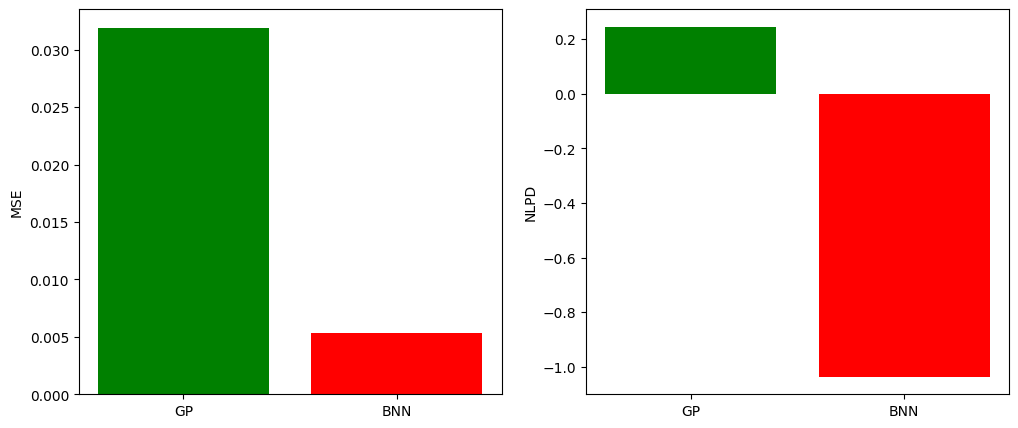

In [7]:
# Labels for the bars
labels = ["GP", "BNN"]
# MSE and NLPD values
mse_values = [mse_gp, mse_bnn]
nlpd_values = [nlpd_gp, nlpd_bnn]
# Colors for each model
colors = ['green', 'red']
# Plot
_, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
ax1.bar(labels, mse_values, color=colors)
ax1.set_ylabel("MSE")
ax2.bar(labels, nlpd_values, color=colors)
ax2.set_ylabel("NLPD")
plt.show()